<a href="https://colab.research.google.com/github/abdulmm44/Student_dropout_prediction/blob/main/Student_dropout_(37).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Team Members:
- Abdulmuhaimin MUHAMMAD
- Pauline KUNDA

## Supervised By:
- Prof. Ikram Chairi
- TA  Ayobami E. Omolusi

### School of Collective Intelligence, UM6P.

## 1. **Problem Statement**
Higher education institutions face significant financial and reputational losses due to student dropout, yet they lack a systematic way to identify which students are likely to drop out before it happens due to the complex nature of the issue.


## 1.1 Main Research Question

How do feature selection, dimensionality reduction, and hyperparameter tuning influence the performance of Logistic Regression and XGBoost models for student retention prediction?

**Sub-Questions**

1. How effectively can Logistic Regression and XGBoost models predict studaent retention outcomes?

2. Which student-related factors are most strongly associated with dropout and retention?

3. How does feature selection affect the predictive performance of student retention models?

4. Which machine learning model achieves the highest predictive performance based on Accuracy, Precision, Recall, F1-Score, and ROC-AUC?

5. What are the most important features contributing to dropout prediction?









## 2. **Data Loading and Target Analysis**
2.1. **Data Loading,  Cleaning and Inspection**



In [1]:
# Importing the necessary libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Feature Selection
from sklearn.feature_selection import (
    SelectKBest,
    chi2,
    mutual_info_classif,
    RFE,
    f_classif
)

# PCA
from sklearn.decomposition import PCA

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
#Reads the dataset from Github
df = pd.read_csv("https://raw.githubusercontent.com/abdulmm44/Student_dropout_prediction/refs/heads/main/data.csv", sep=';')

In [3]:
# understand the data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [4]:
# First five row
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [5]:
#Checking the shape of the dataset
df.shape

(4424, 37)

**Interpretation**

We have:

- 4424 student records
- 36 predictor variables
- 1 target variable (Target)

In [6]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance\t,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [7]:
# check for the missing data
df.isnull().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance\t,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


In [8]:
# check for the duplicates
duplicates = df[df.duplicated()]

print(duplicates)

Empty DataFrame
Columns: [Marital status, Application mode, Application order, Course, Daytime/evening attendance	, Previous qualification, Previous qualification (grade), Nacionality, Mother's qualification, Father's qualification, Mother's occupation, Father's occupation, Admission grade, Displaced, Educational special needs, Debtor, Tuition fees up to date, Gender, Scholarship holder, Age at enrollment, International, Curricular units 1st sem (credited), Curricular units 1st sem (enrolled), Curricular units 1st sem (evaluations), Curricular units 1st sem (approved), Curricular units 1st sem (grade), Curricular units 1st sem (without evaluations), Curricular units 2nd sem (credited), Curricular units 2nd sem (enrolled), Curricular units 2nd sem (evaluations), Curricular units 2nd sem (approved), Curricular units 2nd sem (grade), Curricular units 2nd sem (without evaluations), Unemployment rate, Inflation rate, GDP, Target]
Index: []

[0 rows x 37 columns]


2.2. **Renaming the Columns**

In [81]:
# dictionary mapping the old, messy names to new, clean names
# Format is {'Old Name': 'new_name'}
rename_mapping = {
    'Marital status': 'marital_status',
    'Application mode': 'app_mode',
    'Application order': 'app_order',
    'Daytime/evening attendance\t': 'daytime_attendance',
    'Previous qualification': 'prev_qual',
    'Previous qualification (grade)': 'prev_qual_grade',
    'Admission grade': 'admission_grade',
    'Nacionality': 'nationality',  # Fixing the spelling error
    "Mother's qualification": 'mother_qual',
    "Father's qualification": 'father_qual',
    "Mother's occupation": 'mother_occ',
    "Father's occupation": 'father_occ',
    'Educational special needs': 'special_needs',
    'Tuition fees up to date': 'tuition_current',
    'Scholarship holder': 'scholarship',
    'Age at enrollment': 'age',

    #  extremely long academic performance columns
    'Curricular units 1st sem (credited)': 'sem1_credited',
    'Curricular units 1st sem (enrolled)': 'sem1_enrolled',
    'Curricular units 1st sem (evaluations)': 'sem1_evals',
    'Curricular units 1st sem (approved)': 'sem1_approved',
    'Curricular units 1st sem (grade)': 'sem1_grade',
    'Curricular units 1st sem (without evaluations)': 'sem1_no_evals',

    'Curricular units 2nd sem (credited)': 'sem2_credited',
    'Curricular units 2nd sem (enrolled)': 'sem2_enrolled',
    'Curricular units 2nd sem (evaluations)': 'sem2_evals',
    'Curricular units 2nd sem (approved)': 'sem2_approved',
    'Curricular units 2nd sem (grade)': 'sem2_grade',
    'Curricular units 2nd sem (without evaluations)': 'sem2_no_evals',

    'Unemployment rate': 'unemployment_rate',
    'Inflation rate': 'inflation_rate',
    'GDP': 'gdp',
    'Target': 'target'
}

# Apply the renaming to both our machine dataset (df)
# inplace=True means it updates the dataframe directly without needing to reassign it
df.rename(columns=rename_mapping, inplace=True)

# Total Approved: The sum of curricular units approved in the 1st and 2nd semesters.
df['Total_Approved'] = (
    df['sem1_approved']
    +
    df['sem2_approved']
)


# Average_Grade: The average grade across the 1st and 2nd semesters.
df['Average_Grade'] = (
    df['sem1_grade']
    +
    df['sem2_grade']
)/2

# Average_Sem_Credited = sem1_credited + sem2_credited
df['Average_Sem_Credited'] = (
    df['sem1_credited']
    +
    df['sem2_credited']
)/2

# Average_Sem_evals = sem1_evals + sem2_evals
df['Average_Sem_evals'] = (
    df['sem1_evals']
    +
    df['sem2_evals']
)/2

# Average_Sem_enrolled = sem1_enrolled + sem2_enrolled
df['Average_Sem_enrolled'] = (
    df['sem1_enrolled']
    +
    df['sem2_enrolled']
)/2


# Verify the changes
print(df.columns)

Index(['marital_status', 'app_mode', 'app_order', 'Course',
       'daytime_attendance', 'prev_qual', 'prev_qual_grade', 'nationality',
       'mother_qual', 'father_qual', 'mother_occ', 'father_occ',
       'admission_grade', 'Displaced', 'special_needs', 'Debtor',
       'tuition_current', 'Gender', 'scholarship', 'age', 'International',
       'sem1_credited', 'sem1_enrolled', 'sem1_evals', 'sem1_approved',
       'sem1_grade', 'sem1_no_evals', 'sem2_credited', 'sem2_enrolled',
       'sem2_evals', 'sem2_approved', 'sem2_grade', 'sem2_no_evals',
       'unemployment_rate', 'inflation_rate', 'gdp', 'target',
       'Total_Approved', 'Average_Grade', 'Average_Sem_Credited',
       'Average_Sem_evals', 'Average_Sem_enrolled'],
      dtype='object')


2.3. **Target Variable Analysis**

2.3.1. Original Target Distribution


Percentages:

target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64 




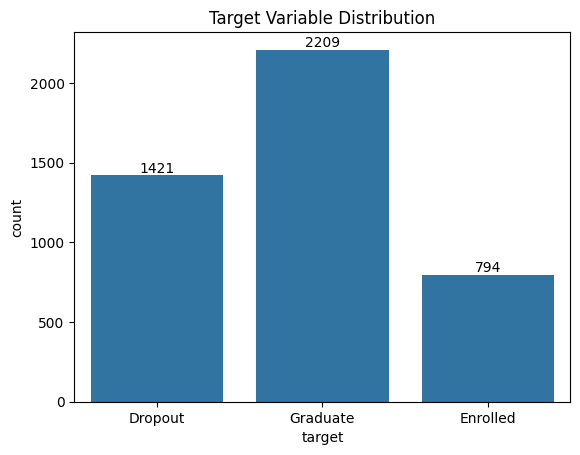

In [82]:
# Target variable analysis - Target Distribution
df['target'].value_counts()

print("\nPercentages:\n")
print(round(df["target"].value_counts(normalize=True)*100,2), "\n\n")

ax = sns.countplot(x='target',data=df)
plt.title('Target Variable Distribution')

# Add count labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

In [83]:
df

,marital_status,app_mode,app_order,Course,daytime_attendance,prev_qual,prev_qual_grade,nationality,mother_qual,father_qual,...,sem2_no_evals,unemployment_rate,inflation_rate,gdp,target,Total_Approved,Average_Grade,Average_Sem_Credited,Average_Sem_evals,Average_Sem_enrolled
0,1,17,5,171,1,1,122.0,1,19,12,...,0,10.8,1.4,1.74,Dropout,0,0.000000,0.0,0.0,0.0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,13.9,-0.3,0.79,Graduate,12,13.833333,0.0,6.0,6.0
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,10.8,1.4,1.74,Dropout,0,0.000000,0.0,0.0,6.0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,9.4,-0.8,-3.12,Graduate,11,12.914286,0.0,9.0,6.0
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,13.9,-0.3,0.79,Graduate,11,12.666667,0.0,7.5,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,15.5,2.8,-4.06,Graduate,10,13.133333,0.0,7.5,6.0
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,11.1,0.6,2.02,Dropout,8,11.500000,0.0,6.0,6.0
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,13.9,-0.3,0.79,Dropout,8,14.206250,0.0,8.5,7.5
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,9.4,-0.8,-3.12,Graduate,10,12.900000,0.0,5.5,5.0


2.3.2. Target Transformation Into Two (2) Classes

In [84]:
# Remove students with unresolved outcomes [Enrolled]

df_model = df[df["target"] != "Enrolled"].copy()

print(f"Original Shape: {df.shape}")
print(f"New Shape: {df_model.shape}")

Original Shape: (4424, 42)
New Shape: (3630, 42)


**Justification of Removing `Enrolled`**

Students classified as `"Enrolled"` were removed from the analysis because their academic outcome remains unresolved. Retaining them would introduce uncertainty into the target variable and potentially bias the predictive models. Therefore, only students with definitive outcomes (`Graduate or Dropout`) were considered.

2.3.3. Vaerifying the Target Class

Target Counts:
target
Graduate    2209
Dropout     1421
Name: count, dtype: int64

Percentages:
target
Graduate    60.85
Dropout     39.15
Name: proportion, dtype: float64


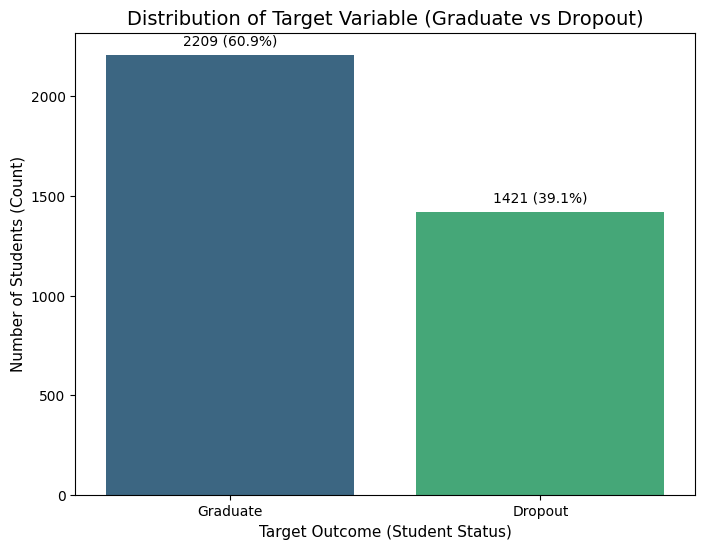

In [85]:
# Verifying Remaining Classes
target_counts = df_model["target"].value_counts()
target_percentages = round(df_model["target"].value_counts(normalize=True) * 100, 2)

print("Target Counts:")
print(target_counts)

print("\nPercentages:")
print(target_percentages)

# Plotting the distribution
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')
plt.title('Distribution of Target Variable (Graduate vs Dropout)', fontsize=14)
plt.xlabel('Target Outcome (Student Status)', fontsize=11)
plt.ylabel('Number of Students (Count)', fontsize=11)

# Add count and percentage labels on top of each bar
for i, p in enumerate(ax.patches):
    height = p.get_height()
    outcome_x = p.get_x() + p.get_width() / 2.
    count = int(height)
    # Get the category name using the index 'i'
    category_name = target_counts.index[i]
    percentage = target_percentages[category_name]
    ax.annotate(f'{count} ({percentage:.1f}%)', (outcome_x, height),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.show()

In [86]:
df_model

,marital_status,app_mode,app_order,Course,daytime_attendance,prev_qual,prev_qual_grade,nationality,mother_qual,father_qual,...,sem2_no_evals,unemployment_rate,inflation_rate,gdp,target,Total_Approved,Average_Grade,Average_Sem_Credited,Average_Sem_evals,Average_Sem_enrolled
0,1,17,5,171,1,1,122.0,1,19,12,...,0,10.8,1.4,1.74,Dropout,0,0.000000,0.0,0.0,0.0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,13.9,-0.3,0.79,Graduate,12,13.833333,0.0,6.0,6.0
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,10.8,1.4,1.74,Dropout,0,0.000000,0.0,0.0,6.0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,9.4,-0.8,-3.12,Graduate,11,12.914286,0.0,9.0,6.0
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,13.9,-0.3,0.79,Graduate,11,12.666667,0.0,7.5,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,15.5,2.8,-4.06,Graduate,10,13.133333,0.0,7.5,6.0
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,11.1,0.6,2.02,Dropout,8,11.500000,0.0,6.0,6.0
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,13.9,-0.3,0.79,Dropout,8,14.206250,0.0,8.5,7.5
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,9.4,-0.8,-3.12,Graduate,10,12.900000,0.0,5.5,5.0


2.3.4 Changing the Target Class into Numerical Value

In [87]:
# changing target variable into binary numerical
df_model['target'] = df_model['target'].replace({
    'Dropout': 1,
    'Graduate': 0
})

print(df_model['target'].value_counts())

print("\nUnique Values:")
print(df_model["target"].unique())


target
0    2209
1    1421
Name: count, dtype: int64

Unique Values:
[1 0]


In [88]:
df_model.T

,0,1,2,3,4,5,6,7,8,9,...,4414,4415,4416,4417,4418,4419,4420,4421,4422,4423
marital_status,1.00,1.000000,1.00,1.000000,2.000000,2.000000,1.0000,1.00,1.000000,1.00,...,1.00,4.000000,1.000,1.000000,1.000000,1.000000,1.00,1.00000,1.00,1.000000
app_mode,17.00,15.000000,1.00,17.000000,39.000000,39.000000,1.0000,18.00,1.000000,1.00,...,1.00,39.000000,43.000,1.000000,44.000000,1.000000,1.00,1.00000,1.00,10.000000
app_order,5.00,1.000000,5.00,2.000000,1.000000,1.000000,1.0000,4.00,3.000000,1.00,...,1.00,1.000000,2.000,1.000000,1.000000,6.000000,2.00,1.00000,1.00,1.000000
Course,171.00,9254.000000,9070.00,9773.000000,8014.000000,9991.000000,9500.0000,9254.00,9238.000000,9238.00,...,9130.00,9500.000000,9500.000,9070.000000,9070.000000,9773.000000,9773.00,9500.00000,9147.00,9773.000000
daytime_attendance,1.00,1.000000,1.00,1.000000,0.000000,0.000000,1.0000,1.00,1.000000,1.00,...,1.00,1.000000,1.000,1.000000,1.000000,1.000000,1.00,1.00000,1.00,1.000000
prev_qual,1.00,1.000000,1.00,1.000000,1.000000,19.000000,1.0000,1.00,1.000000,1.00,...,1.00,19.000000,1.000,1.000000,39.000000,1.000000,1.00,1.00000,1.00,1.000000
prev_qual_grade,122.00,160.000000,122.00,122.000000,100.000000,133.100000,142.0000,119.00,137.000000,138.00,...,137.00,133.100000,136.000,132.000000,120.000000,125.000000,120.00,154.00000,180.00,152.000000
nationality,1.00,1.000000,1.00,1.000000,1.000000,1.000000,1.0000,1.00,62.000000,1.00,...,1.00,1.000000,1.000,1.000000,1.000000,1.000000,105.00,1.00000,1.00,22.000000
mother_qual,19.00,1.000000,37.00,38.000000,37.000000,37.000000,19.0000,37.00,1.000000,1.00,...,3.00,37.000000,38.000,1.000000,3.000000,1.000000,1.00,37.00000,37.00,38.000000
father_qual,12.00,3.000000,37.00,37.000000,38.000000,37.000000,38.0000,37.00,1.000000,19.00,...,38.00,37.000000,38.000,1.000000,38.000000,1.000000,1.00,37.00000,37.00,37.000000


**Target Transformation Summary**


Students with unresolved academic outcomes `"Enrolled"` were excluded from the analysis. This reduced the dataset from **4,424 to 3,630 observations**. The target variable was then transformed into a binary classification problem, where Graduate was encoded as 0 and Dropout as 1. The resulting class distribution was approximately 61% graduates and 39% dropouts, indicating only a mild class imbalance that does not require resampling techniques at this stage.

**2.4. Identify categorical and Numerical Columns**

In [127]:
import numpy as np
# Identify categorical columns (stored as integers but represent categories)
categorical_cols = [
    'marital_status', 'app_mode', 'Course',
    'daytime_attendance', 'prev_qual', 'nationality',
    'mother_qual', 'father_qual', 'mother_occ',
    'father_occ', 'Displaced', 'special_needs', 'Debtor',
    'tuition_current', 'Gender', 'scholarship', 'International'
]

# Identify numerical columns (all other columns)
numerical_cols = [ col for col in df_model.drop("target", axis=1) if col not in categorical_cols]

In [91]:
numerical_cols

['app_order',
 'prev_qual_grade',
 'admission_grade',
 'age',
 'sem1_credited',
 'sem1_enrolled',
 'sem1_evals',
 'sem1_approved',
 'sem1_grade',
 'sem1_no_evals',
 'sem2_credited',
 'sem2_enrolled',
 'sem2_evals',
 'sem2_approved',
 'sem2_grade',
 'sem2_no_evals',
 'unemployment_rate',
 'inflation_rate',
 'gdp',
 'Total_Approved',
 'Average_Grade',
 'Average_Sem_Credited',
 'Average_Sem_evals',
 'Average_Sem_enrolled']

## **2.5. Exploratory Data Analysis (EDA)**
**2.5.1. Creating New Data for EDA**

In [92]:
# the copy of our dataset
df_eda = df_model.copy()
# 3. mapping dictionaries based on the dataset's documentation
gender_map = {1: 'Male', 0: 'Female'}
yes_no_map = {1: 'Yes', 0: 'No'}
marital_status_map = {
    1: 'Single', 2: 'Married', 3: 'Widower',
    4: 'Divorced', 5: 'Facto Union', 6: 'Legally Separated'
}

# 4. Decode the numeric data back into readable text
df_eda['Gender'] = df_eda['Gender'].map(gender_map)
df_eda['daytime_attendance'] = df_eda['daytime_attendance'].map(yes_no_map)
df_eda['special_needs'] = df_eda['special_needs'].map(yes_no_map)
df_eda['scholarship'] = df_eda['scholarship'].map(yes_no_map)
df_eda['Displaced'] = df_eda['Displaced'].map(yes_no_map)
df_eda['Debtor'] = df_eda['Debtor'].map(yes_no_map)
df_eda['tuition_current'] = df_eda['tuition_current'].map(yes_no_map)
df_eda['marital_status'] = df_eda['marital_status'].map(marital_status_map)
df_eda['International'] = df_eda['International'].map(yes_no_map)


# Created the new colum to save the target categorical data
# convert numerical back to categorical target variable

df_eda['target'] = df_eda['target'].replace({
    1 : 'Dropout',
    0 : 'Graduate'

})



# Display the newly decoded features next to the new 'target' variable
cols_to_show = ['Gender', 'marital_status', 'scholarship', 'Debtor','special_needs','daytime_attendance', 'tuition_current', 'target']
print(df_eda[cols_to_show].head())

   Gender marital_status scholarship Debtor special_needs daytime_attendance  \
0    Male         Single          No     No            No                Yes   
1    Male         Single          No     No            No                Yes   
2    Male         Single          No     No            No                Yes   
3  Female         Single          No     No            No                Yes   
4  Female        Married          No     No            No                 No   

  tuition_current    target  
0             Yes   Dropout  
1              No  Graduate  
2              No   Dropout  
3             Yes  Graduate  
4             Yes  Graduate  


In [93]:
df_eda.T

,0,1,2,3,4,5,6,7,8,9,...,4414,4415,4416,4417,4418,4419,4420,4421,4422,4423
marital_status,Single,Single,Single,Single,Married,Married,Single,Single,Single,Single,...,Single,Divorced,Single,Single,Single,Single,Single,Single,Single,Single
app_mode,17,15,1,17,39,39,1,18,1,1,...,1,39,43,1,44,1,1,1,1,10
app_order,5,1,5,2,1,1,1,4,3,1,...,1,1,2,1,1,6,2,1,1,1
Course,171,9254,9070,9773,8014,9991,9500,9254,9238,9238,...,9130,9500,9500,9070,9070,9773,9773,9500,9147,9773
daytime_attendance,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
prev_qual,1,1,1,1,1,19,1,1,1,1,...,1,19,1,1,39,1,1,1,1,1
prev_qual_grade,122.0,160.0,122.0,122.0,100.0,133.1,142.0,119.0,137.0,138.0,...,137.0,133.1,136.0,132.0,120.0,125.0,120.0,154.0,180.0,152.0
nationality,1,1,1,1,1,1,1,1,62,1,...,1,1,1,1,1,1,105,1,1,22
mother_qual,19,1,37,38,37,37,19,37,1,1,...,3,37,38,1,3,1,1,37,37,38
father_qual,12,3,37,37,38,37,38,37,1,19,...,38,37,38,1,38,1,1,37,37,37


**2.5.2 compare numerical value mean with the outcomes**

In [94]:
# Compare numerical features by outcome

df_eda.groupby("target")[numerical_cols].mean().T

target,Dropout,Graduate
app_order,1.593244,1.851064
prev_qual_grade,131.114075,134.082707
admission_grade,124.961365,128.794432
age,26.068966,21.783612
sem1_credited,0.609430,0.847442
sem1_enrolled,5.821253,6.669534
sem1_evals,7.751583,8.276596
sem1_approved,2.551724,6.232232
sem1_grade,7.256656,12.643655
sem1_no_evals,0.192118,0.088275


2.5.3. Correlation Analysis



**2.5.3.1. Correlation Among Features**

It helps you understand how features relate to each other (e.g., if two independent variables are highly correlated, which could indicate multicollinearity).

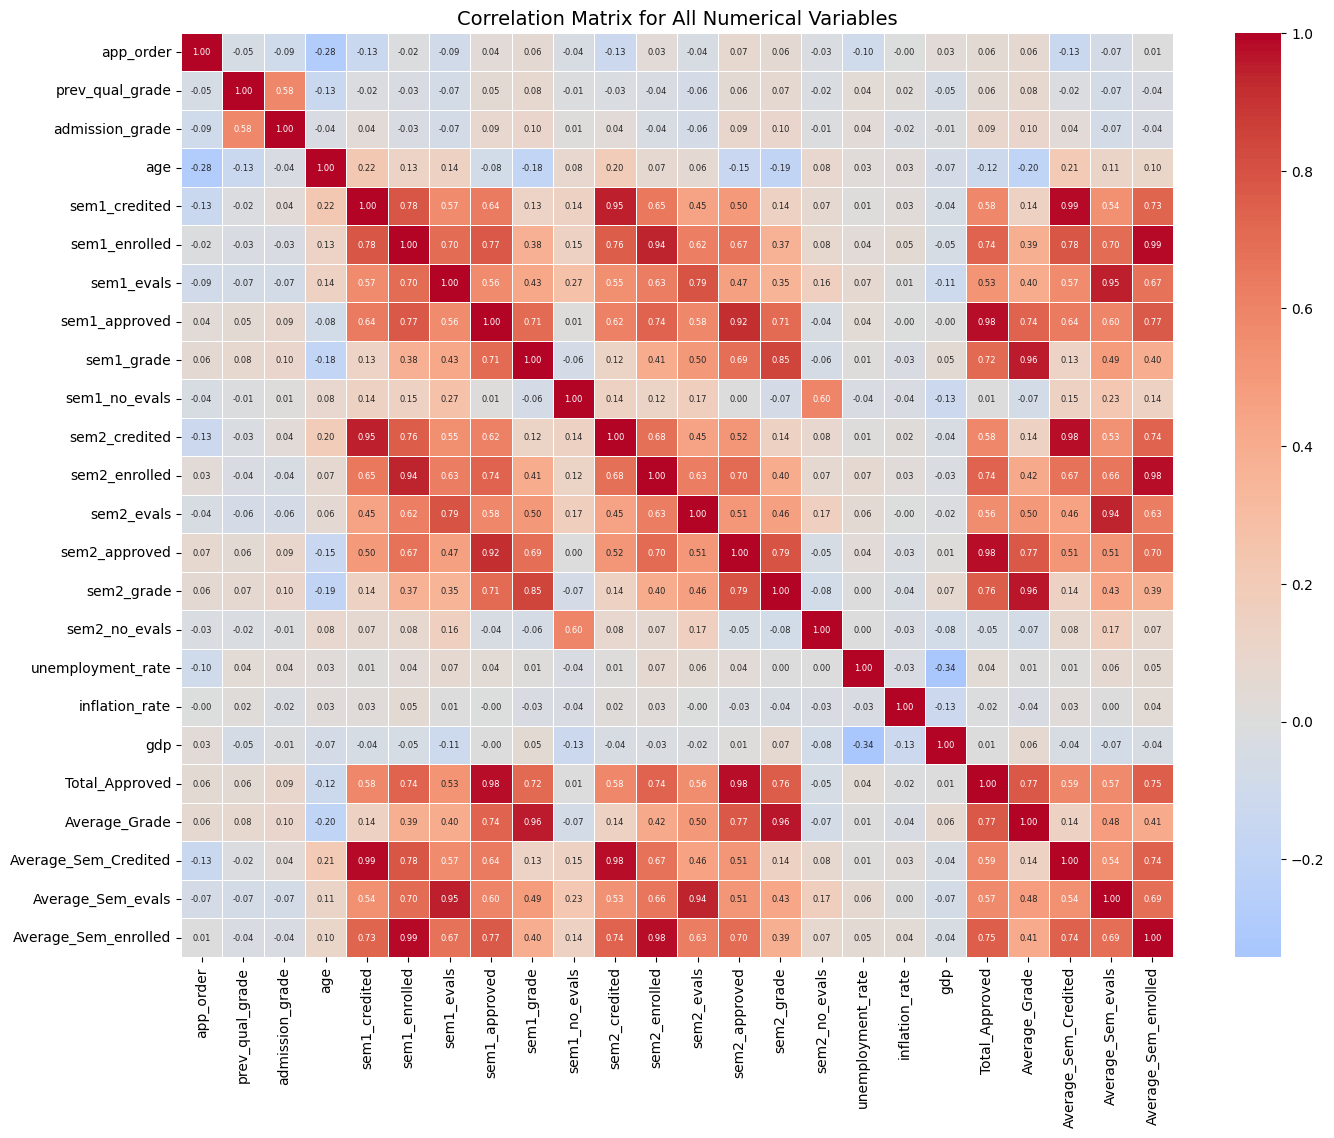

In [95]:
# Correlation Matrix for All Numerical Variables
plt.figure(figsize=(16,12))

corr_matrix = df_model[numerical_cols].corr()

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    center=0,
    annot_kws={'fontsize': 6}
)

plt.title("Correlation Matrix for All Numerical Variables", fontsize = 14)
plt.show()

**Interpretation**

The strongest relationships are observed among academic variables such as approved courses, grades, enrolled courses, and credited courses across both semesters. This suggests that students' academic performance is highly consistent over time and may play an important role in predicting dropout.

**2.5.3.2. Correlation of features with target**

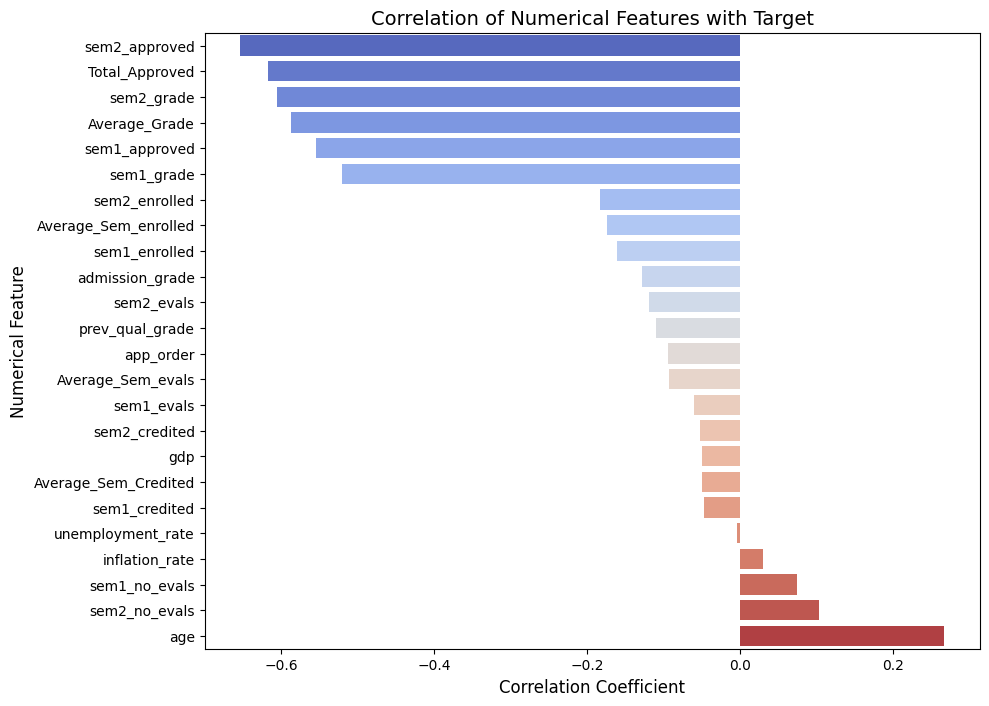

In [96]:
# Correlation of Numerical Features with Target
plt.figure(figsize=(10,8))

# Calculate correlation of all numerical columns with the 'target' column
corr_with_target = df_model[numerical_cols + ['target']].corr()['target']

# Drop the 'target' itself from the series and sort for better visualization
corr_with_target = corr_with_target.drop('target').sort_values(ascending=True)

sns.barplot(
    x=corr_with_target.values,
    y=corr_with_target.index,
    palette='coolwarm' # Using a diverging palette for correlations
)

plt.title("Correlation of Numerical Features with Target", fontsize = 14)
plt.xlabel("Correlation Coefficient", fontsize = 12)
plt.ylabel("Numerical Feature", fontsize = 12)
plt.show()

In [97]:
corr_with_target

,target
sem2_approved,-0.653995
Total_Approved,-0.616893
sem2_grade,-0.605350
Average_Grade,-0.587408
sem1_approved,-0.554881
sem1_grade,-0.519927
sem2_enrolled,-0.182897
Average_Sem_enrolled,-0.173851
sem1_enrolled,-0.161074
admission_grade,-0.128058


**Top Most Correlated Features with the Target**

This is particularly useful for identifying the most impactful features for prediction, regardless of the direction of their influence, as it tells you which features change most predictably with the target.


#Academic Variables
| Feature       | Correlation with Dropout |
| ------------- | -----------------------: |
| sem2_approved |                   -0.654 |
| sem2_grade    |                   -0.605 |
| sem1_approved |                   -0.555 |
| sem1_grade    |                   -0.520 |

# Interpretation
Students who:
- pass more courses,
- obtain higher semester grades,

are substantially less likely to drop out.


# Demographic Variables

| Feature         | Correlation |
| --------------- | ----------: |
| age             |      +0.267 |



#Interpretation

Students who:

- are up-to-date with tuition,
- have scholarships,

are more likely to graduate.

- Students who are debtors are more likely to drop out.

- Older students appear more likely to drop out.

      Possible reasons:

      - Work commitments
      - Family responsibilities
      - Returning to education after a gap


## **Insight (Hypothesis)**:
Academic performance indicators are stronger predictors of student dropout than demographic and socioeconomic characteristics.

 **2.5.4. Academic and  Socioeconomic indicators analysis**


2.5.4.1. Academic Variables

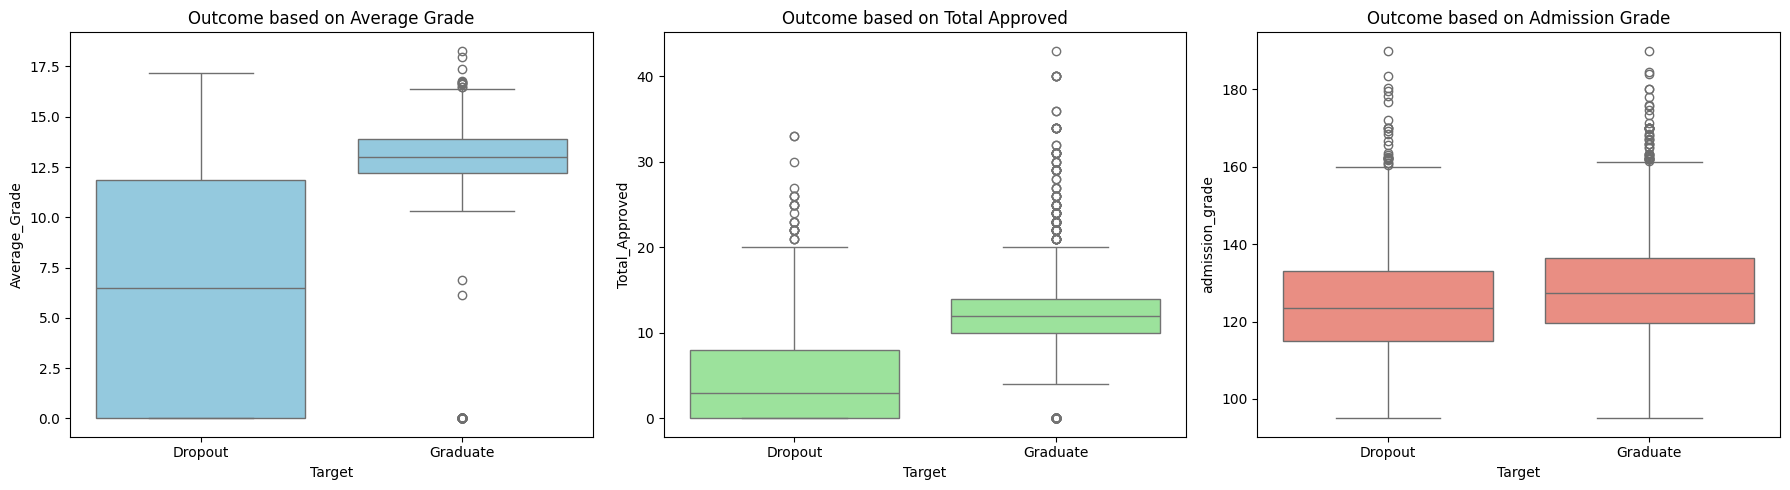

In [98]:
academic_cols = [
    'Average_Grade',
    'Total_Approved',
    'admission_grade'
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18,5)
)

colors = ['skyblue', 'lightgreen', 'salmon']

for ax, col, color in zip(axes, academic_cols, colors):

    sns.boxplot(
        x='target',
        y=col,
        data=df_eda,
        ax=ax,
        color=color
    )

    ax.set_title('Outcome based on ' + col.replace('_', ' ').title())
    ax.set_xlabel('Target')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

**Interpretation**

1. Students with lower academic performance are substantially more likely to drop out. Average grade appears to be one of the strongest indicators of student retention.

2. The number of approved courses strongly differentiates graduates from dropouts. Students who pass fewer courses are at a significantly higher risk of leaving university before completion

3. Admission grade has some relationship with dropout, but its effect is much weaker than current academic performance indicators such as average grade and approved courses. Academic success during university appears to matter more than initial admission performance

The three boxplots suggest that academic performance during university is a much stronger predictor of dropout than admission performance. While graduates and dropouts entered university with relatively similar admission grades, graduates achieved substantially higher average grades and completed many more courses. This indicates that students' academic progress after enrollment is a key factor influencing retention and graduation.

**Outcome Distribution by Attendance Mode**

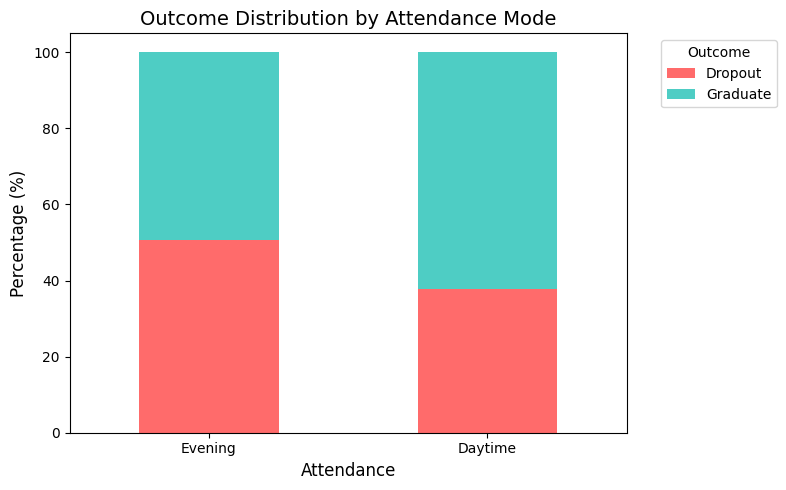

Attendance vs Outcome (%):
target                Dropout   Graduate
daytime_attendance                      
No                  50.735294  49.264706
Yes                 37.678461  62.321539


In [99]:
attendance_outcome = pd.crosstab(df_eda['daytime_attendance'], df_eda['target'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#ff6b6b','#4ecdc4',]
attendance_outcome.plot(kind='bar', stacked=True, ax=ax, color=colors)
ax.set_title('Outcome Distribution by Attendance Mode', fontsize=14)
ax.set_xlabel('Attendance', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Outcome', bbox_to_anchor=(1.05, 1))
ax.set_xticklabels(['Evening', 'Daytime'], rotation=0)
plt.tight_layout()
plt.show()

print("Attendance vs Outcome (%):")
print(attendance_outcome)

**Interpretation**

Students enrolled in Daytime programs have a lower dropout rate (38%) and a higher graduation rate (62%) than students enrolled in Evening programs, where the dropout rate reaches approximately 50%.

Attendance mode appears to influence student outcomes. Evening students are more likely to drop out, possibly due to additional work, family, or personal responsibilities that make academic progression more challenging.

2.5.4.2. Socioeconomic Variables


Outcome analysis by Debts and grades

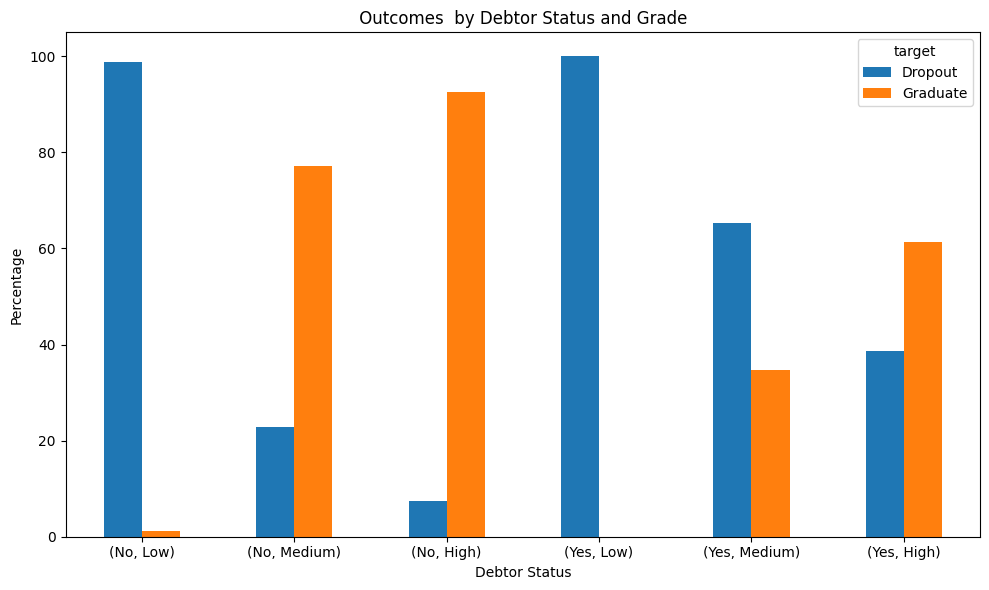

In [100]:
# Creating grade categories
df_eda['Grade_Category'] = pd.cut(
    df_eda['Average_Grade'],
    bins=[0,10,14,20],
    labels=['Low','Medium','High']
)

risk_profile = pd.crosstab(
    [df_eda['Debtor'], df_eda['Grade_Category']],
    df_eda['target'],
    normalize='index'
) * 100




risk_profile.plot(
    kind='bar',
    figsize=(10,6),

)

plt.title(
    ' Outcomes  by Debtor Status and Grade '
)

plt.ylabel('Percentage')
plt.xlabel('Debtor Status')

plt.xticks(
    rotation=0,
    ha='center'
)

plt.tight_layout()
plt.show()

**Interpretation**

Students with low academic performance have the highest dropout rates regardless of debtor status. However, among students with medium and high grades, those with debts are more likely to drop out than non-debtors. This suggests that financial difficulties increase dropout risk, especially when combined with weaker academic performance.



Outcome analysis by Scholarship and Grade

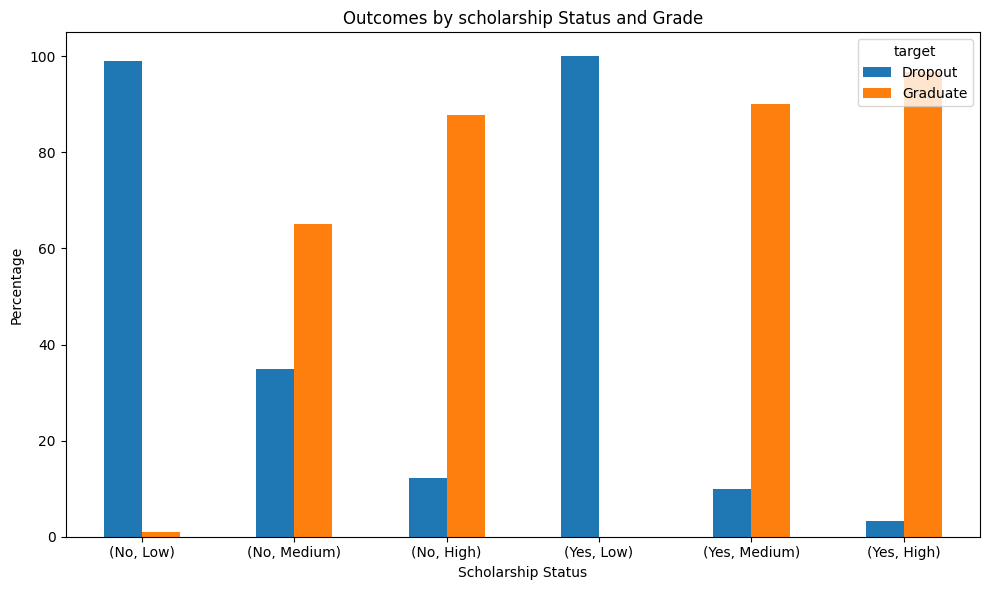

In [101]:
scholarship_profile = pd.crosstab(
    [df_eda['scholarship'], df_eda['Grade_Category']],
    df_eda['target'],
    normalize='index'
) * 100

scholarship_profile.plot(
    kind='bar',
    figsize=(10,6),

)

plt.title(
    'Outcomes by scholarship Status and Grade'
)

plt.ylabel('Percentage')
plt.xlabel('Scholarship Status')

plt.xticks(
    rotation=0,
    ha='center'
)

plt.tight_layout()
plt.show()

**Interpret**

Students with low grades have extremely high dropout rates regardless of scholarship status (about 99–100%). However, among students with medium and high grades, scholarship recipients show lower dropout rates. For example, among high-performing students, the dropout rate decreases from about 12% (non-scholarship) to 3% (scholarship).

Outcomes by Tuition status and grade

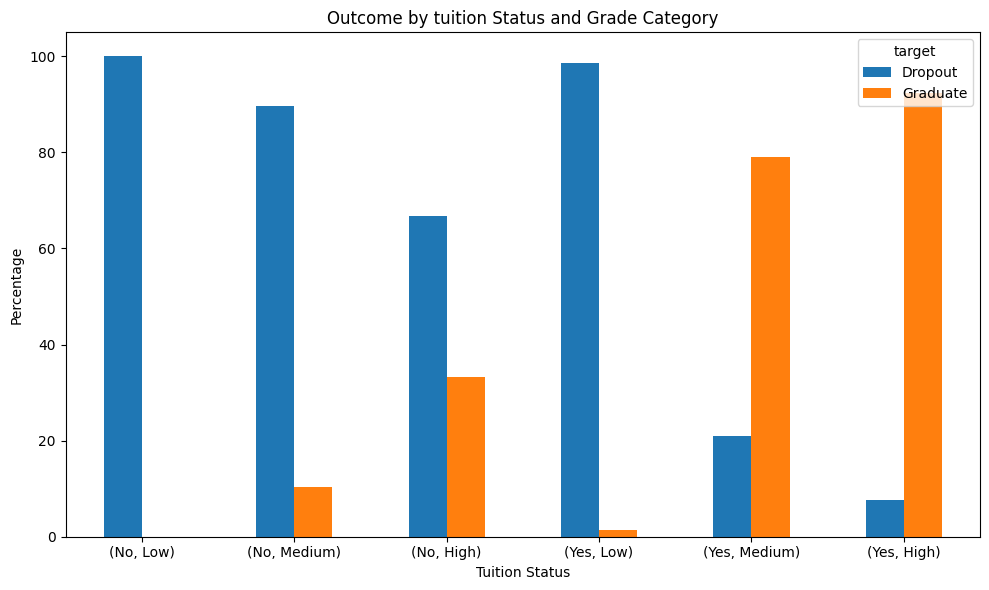

In [102]:
scholarship_profile = pd.crosstab(
    [df_eda['tuition_current'], df_eda['Grade_Category']],
    df_eda['target'],
    normalize='index'
) * 100

scholarship_profile.plot(
    kind='bar',
    figsize=(10,6),

)

plt.title(
    'Outcome by tuition Status and Grade Category'
)

plt.ylabel('Percentage')
plt.xlabel('Tuition Status')

plt.xticks(
    rotation=0,
    ha='center'
)

plt.tight_layout()
plt.show()

**Interpretation**

Students who are not up to date with tuition payments experience substantially higher dropout rates across all grade categories. Even among high-performing students, the dropout rate remains around 67% for students with unpaid tuition, compared to only 8% for students who are up to date.

 **2.5.6. Demographic analysis**



Outcome analysis by marital status

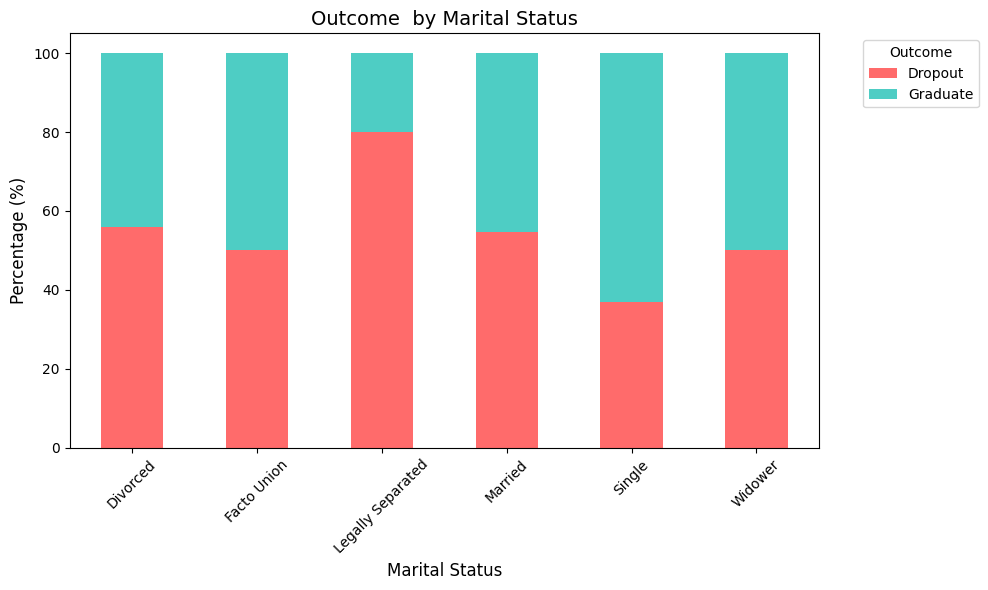

Marital Status vs Outcome (%):
target               Dropout   Graduate
marital_status                         
Divorced           56.000000  44.000000
Facto Union        50.000000  50.000000
Legally Separated  80.000000  20.000000
Married            54.740061  45.259939
Single             37.011566  62.988434
Widower            50.000000  50.000000


In [103]:
marital_outcome = pd.crosstab(df_eda['marital_status'], df_eda['target'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#ff6b6b','#4ecdc4',]
marital_outcome.plot(kind='bar', stacked=True, ax=ax, color=colors)
ax.set_title('Outcome  by Marital Status', fontsize=14)
ax.set_xlabel('Marital Status', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Outcome', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Marital Status vs Outcome (%):")
print(marital_outcome)

**Interpretation**

Dropout rates vary across marital status groups. Legally separated students have the highest dropout rate (80%), followed by divorced students (56%) and married students (55%). In contrast, single students have the lowest dropout rate (37%) and the highest graduation rate (63%).

Students with more complex family or personal responsibilities tend to have higher dropout rates, while single students are more likely to complete their studies successfully.


Outcome analysis by Gender

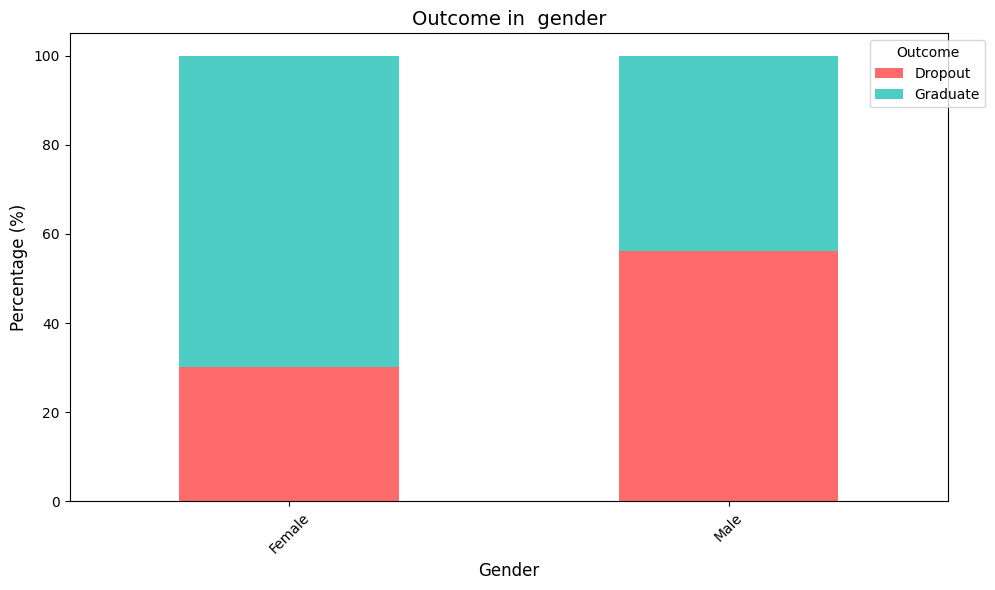

Marital Status vs Outcome (%):
target    Dropout   Graduate
Gender                      
Female  30.239395  69.760605
Male    56.124900  43.875100


In [104]:
marital_outcome = pd.crosstab(df_eda['Gender'], df_eda['target'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#ff6b6b','#4ecdc4',]
marital_outcome.plot(kind='bar', stacked=True, ax=ax, color=colors)
ax.set_title('Outcome in  gender', fontsize=14)
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Outcome', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Marital Status vs Outcome (%):")
print(marital_outcome)

**Interpretation**

Female students have a considerably lower dropout rate (30%) and a higher graduation rate (70%) compared to male students, whose dropout rate is approximately 56% and graduation rate is 44%.

Gender appears to be associated with student retention, with female students showing a higher likelihood of completing their studies than male students.

## **3. Data Processing and Modelling**

**3.1. Creating a Function for Evaluation**

In [105]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }

In [33]:
# Import other libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
np.random.seed(42)


In [106]:
df_model

,marital_status,app_mode,app_order,Course,daytime_attendance,prev_qual,prev_qual_grade,nationality,mother_qual,father_qual,...,sem2_no_evals,unemployment_rate,inflation_rate,gdp,target,Total_Approved,Average_Grade,Average_Sem_Credited,Average_Sem_evals,Average_Sem_enrolled
0,1,17,5,171,1,1,122.0,1,19,12,...,0,10.8,1.4,1.74,1,0,0.000000,0.0,0.0,0.0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,13.9,-0.3,0.79,0,12,13.833333,0.0,6.0,6.0
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,10.8,1.4,1.74,1,0,0.000000,0.0,0.0,6.0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,9.4,-0.8,-3.12,0,11,12.914286,0.0,9.0,6.0
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,13.9,-0.3,0.79,0,11,12.666667,0.0,7.5,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,15.5,2.8,-4.06,0,10,13.133333,0.0,7.5,6.0
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,11.1,0.6,2.02,1,8,11.500000,0.0,6.0,6.0
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,13.9,-0.3,0.79,1,8,14.206250,0.0,8.5,7.5
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,9.4,-0.8,-3.12,0,10,12.900000,0.0,5.5,5.0


**3.2. Feature-Target Split**

In [137]:
# Features and target
X = df_model.drop("target", axis=1)
y = df_model["target"]

# Columns to remove due to high correlation with each other and the new engineered features
columns_to_remove = [
    'sem1_approved', 'sem1_credited', 'sem1_enrolled', 'sem1_grade', 'sem1_evals',
    'sem2_approved', 'sem2_credited', 'sem2_enrolled', 'sem2_grade', 'sem2_evals'
]

# Drop the specified columns from X if they exist
X = X.drop(columns=columns_to_remove, errors='ignore')

# Update the global numerical_cols and categorical_cols based on the actual columns in X
current_cols_in_X = X.columns.tolist()
global numerical_cols
global categorical_cols
numerical_cols = [col for col in numerical_cols if col in current_cols_in_X]
categorical_cols = [col for col in categorical_cols if col in current_cols_in_X]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (3630, 31)
Target Shape: (3630,)


In [138]:
X.T

,0,1,2,3,4,5,6,7,8,9,...,4414,4415,4416,4417,4418,4419,4420,4421,4422,4423
marital_status,1.00,1.000000,1.00,1.000000,2.000000,2.000000,1.0000,1.00,1.000000,1.00,...,1.00,4.000000,1.000,1.000000,1.000000,1.000000,1.00,1.00000,1.00,1.000000
app_mode,17.00,15.000000,1.00,17.000000,39.000000,39.000000,1.0000,18.00,1.000000,1.00,...,1.00,39.000000,43.000,1.000000,44.000000,1.000000,1.00,1.00000,1.00,10.000000
app_order,5.00,1.000000,5.00,2.000000,1.000000,1.000000,1.0000,4.00,3.000000,1.00,...,1.00,1.000000,2.000,1.000000,1.000000,6.000000,2.00,1.00000,1.00,1.000000
Course,171.00,9254.000000,9070.00,9773.000000,8014.000000,9991.000000,9500.0000,9254.00,9238.000000,9238.00,...,9130.00,9500.000000,9500.000,9070.000000,9070.000000,9773.000000,9773.00,9500.00000,9147.00,9773.000000
daytime_attendance,1.00,1.000000,1.00,1.000000,0.000000,0.000000,1.0000,1.00,1.000000,1.00,...,1.00,1.000000,1.000,1.000000,1.000000,1.000000,1.00,1.00000,1.00,1.000000
prev_qual,1.00,1.000000,1.00,1.000000,1.000000,19.000000,1.0000,1.00,1.000000,1.00,...,1.00,19.000000,1.000,1.000000,39.000000,1.000000,1.00,1.00000,1.00,1.000000
prev_qual_grade,122.00,160.000000,122.00,122.000000,100.000000,133.100000,142.0000,119.00,137.000000,138.00,...,137.00,133.100000,136.000,132.000000,120.000000,125.000000,120.00,154.00000,180.00,152.000000
nationality,1.00,1.000000,1.00,1.000000,1.000000,1.000000,1.0000,1.00,62.000000,1.00,...,1.00,1.000000,1.000,1.000000,1.000000,1.000000,105.00,1.00000,1.00,22.000000
mother_qual,19.00,1.000000,37.00,38.000000,37.000000,37.000000,19.0000,37.00,1.000000,1.00,...,3.00,37.000000,38.000,1.000000,3.000000,1.000000,1.00,37.00000,37.00,38.000000
father_qual,12.00,3.000000,37.00,37.000000,38.000000,37.000000,38.0000,37.00,1.000000,19.00,...,38.00,37.000000,38.000,1.000000,38.000000,1.000000,1.00,37.00000,37.00,37.000000


**3.3 Train/Test Split**

In [139]:
# split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (2904, 31)
Testing Set : (726, 31)


In [140]:
# Verify Class Distribution
print("Overall:")
print(y.value_counts(normalize=True))

print("\nTrain:")
print(y_train.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

Overall:
target
0    0.60854
1    0.39146
Name: proportion, dtype: float64

Train:
target
0    0.608471
1    0.391529
Name: proportion, dtype: float64

Test:
target
0    0.608815
1    0.391185
Name: proportion, dtype: float64


**3.4 Statistical Baseline: Dummy Classifier**

It is used as a baseline to determine whether more sophisticated models are actually adding predictive value. Can we beat a model that does not learn anything?

In [141]:
baseline_dummy = DummyClassifier(strategy='most_frequent')

baseline_dummy.fit(X_train, y_train)

baseline_dummy_pred = baseline_dummy.predict(X_test)

# Create a proper metrics dictionary (same structure as evaluate_model output)
baseline_dummy_scores = {
    "Accuracy": accuracy_score(y_test, baseline_dummy_pred),
    "Precision": precision_score(y_test, baseline_dummy_pred),
    "Recall": recall_score(y_test, baseline_dummy_pred),
    "F1": f1_score(y_test, baseline_dummy_pred),
    "ROC_AUC": roc_auc_score(y_test, baseline_dummy_pred),
    "Model": "DummyClassifier",
    "Experiment": "Baseline_Dummy"
}

# Convert it into DataFrame
results_baseline_dummy = pd.DataFrame([baseline_dummy_scores])
results_baseline_dummy

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.608815,0.0,0.0,0.0,0.5,DummyClassifier,Baseline_Dummy


**3.5 Preprocessing Pipeline**

In [142]:
# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_cols)
    ])

**Applying Preprocessing for Scaled Data**

Before applying RFE and PCA, we need to transform our `X_train` and `X_test` datasets using the defined `preprocessor`. This step scales numerical features and one-hot encodes categorical features, creating `X_train_scaled` and `X_test_scaled`.

In [143]:
# Apply the preprocessor to X_train and X_test
X_train_scaled = preprocessor.fit_transform(X_train, y_train)
X_test_scaled = preprocessor.transform(X_test)

print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)

Shape of X_train_scaled: (2904, 230)
Shape of X_test_scaled: (726, 230)


With `X_train_scaled` and `X_test_scaled` now available, the RFE and PCA steps will execute without the `NameError`.

**3.6. ML Baseline: Logistic Regression**

This is our first real machine learning model.

In [144]:
# Create full pipeline with Logistic Regression
log_reg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])


# Train the model
log_reg_model.fit(X_train, y_train)

# predict the model
baseline_lr_pred = log_reg_model.predict(X_test)

# Create a proper metrics dictionary (same structure as evaluate_model output)
log_reg_model_score= {
    "Accuracy": accuracy_score(y_test,baseline_lr_pred ),
    "Precision": precision_score(y_test, baseline_lr_pred ),
    "Recall": recall_score(y_test, baseline_lr_pred ),
    "F1": f1_score(y_test, baseline_lr_pred ),
    "ROC_AUC": roc_auc_score(y_test, baseline_lr_pred ),
    "Model": "Logistic regression",
    "Experiment": "Baseline_LogisticRegression"
}

# Convert it into DataFrame
results_baseline_regression = pd.DataFrame([log_reg_model_score])
results_baseline_regression


,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.922865,0.893103,0.911972,0.902439,0.920918,Logistic regression,Baseline_LogisticRegression


In [145]:
X_train.shape
X_test.shape

(726, 31)

**3.7 Confusion matrix for Baseline logistic regression**

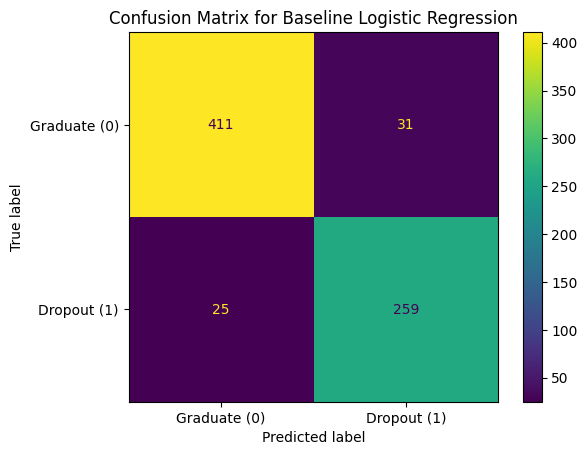

In [146]:
# Compute confusion matrix for baseline_lr
cm_baseline_lr = confusion_matrix(
    y_test,
    baseline_lr_pred
)

# Display confusion matrix visually
ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline_lr,
    display_labels=['Graduate (0)', 'Dropout (1)']
).plot()

plt.title('Confusion Matrix for Baseline Logistic Regression')
plt.show()

**3.8 Dummy model and baseline logistic regression comparison**

In [147]:
baseline_results = pd.DataFrame({
    "DummyClassifier": baseline_dummy_scores,
    "Logistic Regression": log_reg_model_score
})

baseline_results.T

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
DummyClassifier,0.608815,0.0,0.0,0.0,0.5,DummyClassifier,Baseline_Dummy
Logistic Regression,0.922865,0.893103,0.911972,0.902439,0.920918,Logistic regression,Baseline_LogisticRegression


**Interpretation:**

A simple Log Reg using all features is already achieving high accuracy.

`Now, Can we achieve similar performance using fewer features?`



## **4. Feature Selection**

**To test the following hypothesis:**

H₀: Feature selection does not improve performance.

H₁: Feature selection can maintain or improve performance while reducing dimensionality.

**4.1. LR + Filter Method (SelectBest using F-Score)**

In [186]:
lr_kbest = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_classif, k=15)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

lr_kbest.fit(X_train, y_train)

y_pred = lr_kbest.predict(X_test)
y_prob = lr_kbest.predict_proba(X_test)[:, 1]

lr_kbest_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob),
    "Model": "LR + Filter Method",
    "Experiment": "SelectKBest"
}

lr_kbest_results = pd.DataFrame([lr_kbest_results])
lr_kbest_results

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.935262,0.915789,0.919014,0.917399,0.969656,LR + Filter Method,SelectKBest


In [190]:
selected_features_indices = lr_kbest.named_steps['feature_selection'].get_support(indices=True)
all_features = lr_kbest.named_steps['preprocessor'].get_feature_names_out()
kbest_selected_features = all_features[selected_features_indices]
print("Features selected by SelectKBest:")
print(kbest_selected_features)
print(f"\nNumber of features selected by SelectKBest: {len(kbest_selected_features)}\n")

Features selected by SelectKBest:
['cat__app_mode_1' 'cat__app_mode_39' 'cat__Course_9500' 'cat__Debtor_0'
 'cat__Debtor_1' 'cat__tuition_current_0' 'cat__tuition_current_1'
 'cat__Gender_0' 'cat__Gender_1' 'cat__scholarship_0' 'cat__scholarship_1'
 'remainder__age' 'remainder__Total_Approved' 'remainder__Average_Grade'
 'remainder__Average_Sem_enrolled']

Number of features selected by SelectKBest: 15



In [191]:
cleaned_kbest_features_temp = []
for col in kbest_selected_features:
    # Remove 'num__' or 'cat__' prefixes
    clean_col = col.replace('num__', '').replace('cat__', '')

    # Check if the feature is a numerical one that might have underscores (e.g., sem1_grade)
    # If it's not a known numerical feature, and it contains an underscore,
    # assume it's a one-hot encoded categorical feature and take the part before the first underscore.
    if clean_col not in numerical_cols and '_' in clean_col:
        cleaned_kbest_features_temp.append(clean_col.split('_', 1)[0])
    else:
        cleaned_kbest_features_temp.append(clean_col)

# Get unique features and sort them
cleaned_kbest_features = sorted(list(set(cleaned_kbest_features_temp)))

print("Original features selected by SelectKBest:")
print(cleaned_kbest_features)
print(f"\nNumber of original features selected by SelectKBest: {len(cleaned_kbest_features)}\n")

Original features selected by SelectKBest:
['Course', 'Debtor', 'Gender', 'app', 'remainder', 'scholarship', 'tuition']

Number of original features selected by SelectKBest: 7



**4.2. LR +  Wrapper Method (RFE)**

In [201]:
rfe_estimator = LogisticRegression(max_iter=1000, random_state=42)

lr_rfe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', RFE(
        estimator=rfe_estimator,
        n_features_to_select=17,
        step=0.1
    )),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

lr_rfe.fit(X_train, y_train)

y_pred = lr_rfe.predict(X_test)
y_prob = lr_rfe.predict_proba(X_test)[:, 1]


lr_rfe_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob),
    "Model": "LR + RFE",
    "Experiment": "RFE"
}

lr_rfe_results = pd.DataFrame([lr_rfe_results])
lr_rfe_results

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.932507,0.933579,0.890845,0.911712,0.972735,LR + RFE,RFE


In [202]:
selected_features_rfe_indices = lr_rfe.named_steps['feature_selection'].get_support(indices=True)
all_features_preprocessed = lr_rfe.named_steps['preprocessor'].get_feature_names_out()
rfe_selected_features = all_features_preprocessed[selected_features_rfe_indices]

cleaned_rfe_features_temp = []
for col in rfe_selected_features:
    # Remove 'num__' or 'cat__' prefixes
    clean_col = col.replace('num__', '').replace('cat__', '')

    # If it's a categorical feature (indicated by _ and not a numerical column name),
    # take the part before the first underscore (e.g., 'app_mode_1' -> 'app_mode').
    # Otherwise, keep the cleaned column name.
    if clean_col not in numerical_cols and '_' in clean_col and clean_col.split('_')[0] in categorical_cols:
        cleaned_rfe_features_temp.append(clean_col.split('_')[0])
    else:
        cleaned_rfe_features_temp.append(clean_col)

# Get unique features and sort them
cleaned_rfe_features = sorted(list(set(cleaned_rfe_features_temp)))

print("Features selected by RFE:")
for feature in cleaned_rfe_features:
    print(f"- {feature}")
print(f"\nNumber of features selected by RFE: {len(cleaned_rfe_features)}")

Features selected by RFE:
- Course
- app_mode_51
- father_qual_39
- mother_qual_12
- mother_qual_34
- nationality
- prev_qual_4
- remainder__Average_Sem_enrolled
- remainder__Total_Approved
- scholarship
- tuition_current_0
- tuition_current_1

Number of features selected by RFE: 12


In [203]:
selected_features_rfe_indices = lr_rfe.named_steps['feature_selection'].get_support(indices=True)
all_features_preprocessed = lr_rfe.named_steps['preprocessor'].get_feature_names_out()
rfe_selected_features = all_features_preprocessed[selected_features_rfe_indices]

cleaned_rfe_features_temp = []
for col in rfe_selected_features:
    # Remove 'num__' or 'cat__' prefixes
    clean_col = col.replace('num__', '').replace('cat__', '')

    is_grouped = False
    for cat_feature_name in categorical_cols:
        # Check if the cleaned column starts with a categorical feature name and contains an underscore
        # This handles cases like 'app_mode_1' -> 'app_mode' and also 'prev_qual_4' -> 'prev_qual'
        if clean_col.startswith(cat_feature_name) and '_' in clean_col and clean_col != cat_feature_name:
            cleaned_rfe_features_temp.append(cat_feature_name)
            is_grouped = True
            break # Found a match, no need to check other categorical_cols

    if not is_grouped:
        # If it wasn't grouped by a categorical feature (e.g., it's a numerical feature or not OHE)
        cleaned_rfe_features_temp.append(clean_col)

# Get unique features and sort them
cleaned_rfe_features = sorted(list(set(cleaned_rfe_features_temp)))

print("Features selected by RFE:")
for feature in cleaned_rfe_features:
    print(f"- {feature}")
print(f"\nNumber of features selected by RFE: {len(cleaned_rfe_features)}")

Features selected by RFE:
- Course
- app_mode
- father_qual
- mother_qual
- nationality
- prev_qual
- remainder__Average_Sem_enrolled
- remainder__Total_Approved
- scholarship
- tuition_current

Number of features selected by RFE: 10


**4.3. LR +  Embedded Method**

In [217]:
# User can adjust C_param_for_l1 to control the number of selected features (sparsity).
# Smaller C values lead to stronger regularization and fewer selected features.
# The default C is 1.0. Adjusting this value will change the number of selected features.
C_param_for_l1 = 0.13

lr_embedded = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        penalty='l1',
        solver='saga',      # required for L1
        max_iter=2000,
        random_state=42,
        C=C_param_for_l1 # Use the adjustable C parameter
    ))
])

lr_embedded.fit(X_train, y_train)

y_pred = lr_embedded.predict(X_test)
y_prob = lr_embedded.predict_proba(X_test)[:, 1]

lr_embedded_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob),
    "Model": "LR + Embedded",
    "Experiment": "Embedded"
}

lr_embedded_results = pd.DataFrame([lr_embedded_results])
lr_embedded_results

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.928375,0.911348,0.90493,0.908127,0.970341,LR + Embedded,Embedded


In [218]:
classifier_model = lr_embedded.named_steps['classifier']
coefficients = classifier_model.coef_[0]

# Get feature names after preprocessing
preprocessor_feature_names = lr_embedded.named_steps['preprocessor'].get_feature_names_out()

# Identify selected features (non-zero coefficients)
selected_features_indices = np.where(coefficients != 0)[0]
selected_features_count = len(selected_features_indices)
selected_feature_names = preprocessor_feature_names[selected_features_indices]

print(f"Number of features selected by LR + Embedded: {selected_features_count}")
print("Selected features:")
for feature in selected_feature_names:
    print(f"- {feature}")

Number of features selected by LR + Embedded: 33
Selected features:
- cat__app_mode_1
- cat__app_mode_17
- cat__Course_8014
- cat__Course_9238
- cat__Course_9773
- cat__Course_9853
- cat__mother_occ_9
- cat__father_occ_4
- cat__father_occ_6
- cat__Displaced_0
- cat__Displaced_1
- cat__Debtor_0
- cat__Debtor_1
- cat__tuition_current_0
- cat__tuition_current_1
- cat__Gender_0
- cat__Gender_1
- cat__scholarship_0
- cat__scholarship_1
- remainder__app_order
- remainder__prev_qual_grade
- remainder__admission_grade
- remainder__age
- remainder__sem1_no_evals
- remainder__sem2_no_evals
- remainder__unemployment_rate
- remainder__inflation_rate
- remainder__gdp
- remainder__Total_Approved
- remainder__Average_Grade
- remainder__Average_Sem_Credited
- remainder__Average_Sem_evals
- remainder__Average_Sem_enrolled


In [220]:
cleaned_embedded_features_temp = []
for col in selected_feature_names:
    if col.startswith('num__'):
        # It's a numerical feature, remove prefix and add
        cleaned_embedded_features_temp.append(col.replace('num__', ''))
    elif col.startswith('cat__'):
        # It's a categorical feature, remove prefix and get the base name
        clean_cat_col = col.replace('cat__', '')
        cleaned_embedded_features_temp.append(clean_cat_col.split('_')[0])

# Get unique features and sort them
original_embedded_features = sorted(list(set(cleaned_embedded_features_temp)))

print("Original features selected by LR + Embedded:")
for feature in original_embedded_features:
    print(f"- {feature}")
print(f"\nNumber of features selected by LR + Embedded: {len(original_embedded_features)}")

Original features selected by LR + Embedded:
- Course
- Debtor
- Displaced
- Gender
- app
- father
- mother
- scholarship
- tuition

Number of features selected by LR + Embedded: 9


**4.4. LR + PCA (Principal Component Analysis)**

In [224]:
lr_pca = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=10)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

lr_pca.fit(X_train, y_train)

y_pred = lr_pca.predict(X_test)
y_prob = lr_pca.predict_proba(X_test)[:, 1]

lr_pca_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob),
    "Model": "LR + PCA",
    "Experiment": "PCA"
}

lr_pca_results = pd.DataFrame([lr_pca_results])
lr_pca_results

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.867769,0.850746,0.802817,0.826087,0.928056,LR + PCA,PCA


Number of components retained by PCA: 10




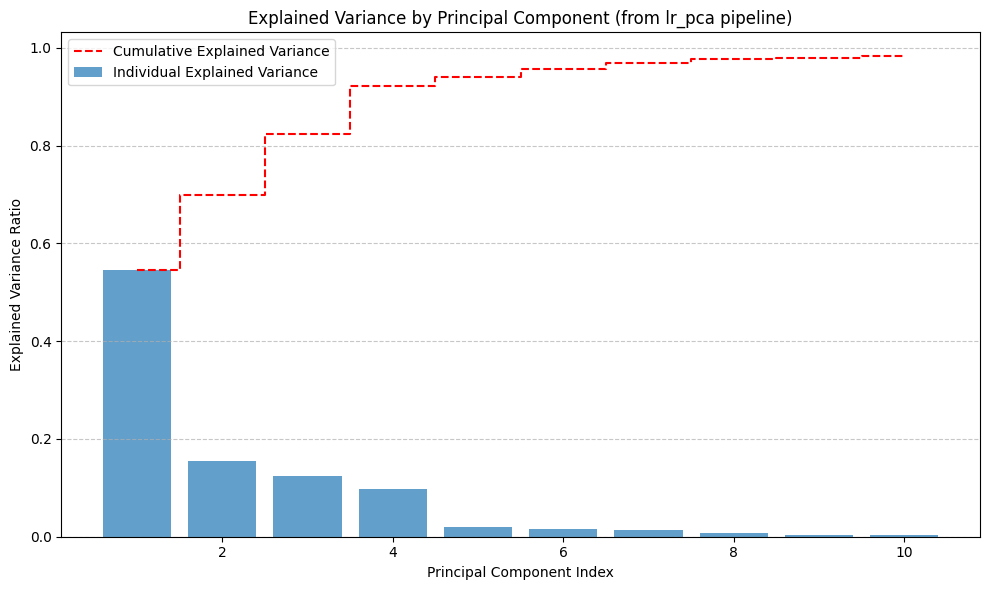

In [225]:
pca_model = lr_pca.named_steps['pca']
n_components = pca_model.n_components_
explained_variance = pca_model.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"Number of components retained by PCA: {n_components}\n\n")

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, label='Individual Explained Variance')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Cumulative Explained Variance', linestyle='--', color='red')
plt.xlabel('Principal Component Index')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Component (from lr_pca pipeline)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **5. XGBoost Model**

**5.1. XGBoost Baseline with no Dimensionality Reduction**

In [226]:
preprocessor_xgb_no_fs = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'  # keeps numerical features as they are
)

# XGBoost model without feature selection
xgb_no_fs_model = Pipeline(steps=[
    ('preprocessor', preprocessor_xgb_no_fs),
    ('classifier', XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    ))
])

# Train model
xgb_no_fs_model.fit(X_train, y_train)

# Predictions
y_pred_no_fs = xgb_no_fs_model.predict(X_test)
y_prob_no_fs = xgb_no_fs_model.predict_proba(X_test)[:, 1]

# Evaluation
xgb_no_fs_results = {
    "Accuracy": accuracy_score(y_test, y_pred_no_fs),
    "Precision": precision_score(y_test, y_pred_no_fs),
    "Recall": recall_score(y_test, y_pred_no_fs),
    "F1": f1_score(y_test, y_pred_no_fs),
    "ROC_AUC": roc_auc_score(y_test, y_prob_no_fs),
    "Model": "XGBoost",
    "Experiment": "No_Feature_Selection"
}

xgb_no_fs_results = pd.DataFrame([xgb_no_fs_results])
xgb_no_fs_results

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.929752,0.908772,0.911972,0.910369,0.973886,XGBoost,No_Feature_Selection


**5.2. XGBoost + Filter Method**

In [227]:
# Preprocessing (NO scaling needed for XGBoost)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'  # keeps numerical features as they are
)

# User-defined number of features for SelectKBest
k_features_xgb = 15 # You can change this value to select a different number of features

# XGBoost baseline model with feature selection
xgb_KBest = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_classif, k=k_features_xgb)), # Added feature selection
    ('classifier', XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    ))
])

# Train model
xgb_KBest.fit(X_train, y_train)

# Predictions
y_pred = xgb_KBest.predict(X_test)
y_prob = xgb_KBest.predict_proba(X_test)[:, 1]

# Evaluation
xgb_KBest_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob),
    "Model": "XGBoost",
    "Experiment": "KBest"
}

xgb_KBest_results = pd.DataFrame([xgb_KBest_results])
xgb_KBest_results

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.935262,0.930909,0.901408,0.915921,0.959196,XGBoost,KBest


In [228]:
preprocessor_fitted = xgb_KBest.named_steps['preprocessor']
feature_names_after_preprocessor = preprocessor_fitted.get_feature_names_out()

# Get the indices of the features selected by SelectKBest
selected_features_mask = xgb_KBest.named_steps['feature_selection'].get_support()
selected_preprocessed_features = feature_names_after_preprocessor[selected_features_mask]

cleaned_xgb_features_temp = []
for col in selected_preprocessed_features:
    if col.startswith('cat__'):
        # It's a categorical feature, remove prefix and get the base name
        clean_cat_col = col.replace('cat__', '')
        # Split by the first underscore to get the original feature name
        original_feature = clean_cat_col.split('_', 1)[0] # Split only on the first underscore
        cleaned_xgb_features_temp.append(original_feature)
    elif col.startswith('remainder__'):
        # It's a numerical feature passed through, remove prefix
        cleaned_xgb_features_temp.append(col.replace('remainder__', ''))

# Get unique features and sort them
original_xgb_selected_features = sorted(list(set(cleaned_xgb_features_temp)))

print("Original features selected by the XGBoost model with SelectKBest:")
for feature in original_xgb_selected_features:
    print(f"- {feature}")

print(f"\nTotal number of original features selected: {len(original_xgb_selected_features)}")

Original features selected by the XGBoost model with SelectKBest:
- Average_Grade
- Average_Sem_enrolled
- Course
- Debtor
- Gender
- Total_Approved
- age
- app
- scholarship
- tuition

Total number of original features selected: 10


**5.3. XGBoost + RFE**

In [229]:
# Preprocessing (NO scaling needed for XGBoost)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'  # keeps numerical features
)

# Base estimator for RFE (must be a simple model)
estimator = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# RFE wrapper
xgb_rfe = RFE(
    estimator=estimator,
    n_features_to_select=13,  # you can tune this
    step=0.1
)

# Full pipeline: Preprocessing → RFE → XGBoost
xgb_rfe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', xgb_rfe),
    ('classifier', XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    ))
])

# Train model
xgb_rfe.fit(X_train, y_train)

# Predictions
y_pred = xgb_rfe.predict(X_test)
y_prob = xgb_rfe.predict_proba(X_test)[:, 1]

# Evaluation
xgb_rfe_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob),
    "Model": "XGBoost + RFE",
    "Experiment": "Wrapper_RFE"
}

xgb_rfe_results = pd.DataFrame([xgb_rfe_results])
xgb_rfe_results

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.928375,0.889262,0.933099,0.910653,0.967374,XGBoost + RFE,Wrapper_RFE


In [232]:
selected_features_rfe_indices = xgb_rfe.named_steps['feature_selection'].get_support(indices=True)
feature_names_after_preprocessor = xgb_rfe.named_steps['preprocessor'].get_feature_names_out()
rfe_selected_features = feature_names_after_preprocessor[selected_features_rfe_indices]

cleaned_xgb_rfe_features_temp = []
for col in rfe_selected_features:
    # Remove 'remainder__' or 'cat__' prefixes
    clean_col = col.replace('remainder__', '').replace('cat__', '')

    is_grouped = False
    for cat_feature_name in categorical_cols:
        # Check if the cleaned column starts with a categorical feature name and contains an underscore
        # This handles cases like 'app_mode_1' -> 'app_mode' and also 'prev_qual_4' -> 'prev_qual'
        if clean_col.startswith(cat_feature_name) and '_' in clean_col and clean_col != cat_feature_name:
            cleaned_xgb_rfe_features_temp.append(cat_feature_name)
            is_grouped = True
            break # Found a match, no need to check other categorical_cols

    if not is_grouped:
        # If it wasn't grouped by a categorical feature (e.g., it's a numerical feature or not OHE)
        cleaned_xgb_rfe_features_temp.append(clean_col)

# Get unique features and sort them
original_xgb_rfe_selected_features = sorted(list(set(cleaned_xgb_rfe_features_temp)))

print("Original features selected by the XGBoost model with RFE:")
for feature in original_xgb_rfe_selected_features:
    print(f"- {feature}")

print(f"\nTotal number of original features selected: {len(original_xgb_rfe_selected_features)}")

Original features selected by the XGBoost model with RFE:
- Average_Sem_Credited
- Average_Sem_enrolled
- Average_Sem_evals
- Course
- Debtor
- Gender
- Total_Approved
- app_mode
- scholarship
- tuition_current

Total number of original features selected: 10


**5.4. XGBoost with Embedded Method**

In [233]:
# Preprocessing (NO scaling needed)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

# XGBoost (Embedded feature selection happens here)
xgb_embedded_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.7,  # key embedded control
        reg_lambda=1.0,
        reg_alpha=0.0,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    ))
])

# Train
xgb_embedded_model.fit(X_train, y_train)

# Predict
y_pred = xgb_embedded_model.predict(X_test)
y_prob = xgb_embedded_model.predict_proba(X_test)[:, 1]

# Evaluate
xgb_embedded_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob),
    "Model": "XGBoost (Embedded)",
    "Experiment": "Embedded_XGB"
}

xgb_embedded_results = pd.DataFrame([xgb_embedded_results])
xgb_embedded_results

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.926997,0.908127,0.90493,0.906526,0.974516,XGBoost (Embedded),Embedded_XGB


## **6. Tuning the best model based on F1**

**6.1. Hyperparameter tuning for Logistic Regression with RFE**

In [234]:
# Hyperparameter tuning for Logistic Regression with RFE

# Define the parameter grid for Logistic Regression and RFE
param_grid = {
    'feature_selection__n_features_to_select': [10, 12, 14, 16, 18, 20],
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2']
}

# Create the GridSearchCV object
grid_search_lr_rfe = GridSearchCV(
    estimator=lr_rfe,
    param_grid=param_grid,
    cv=5,
    scoring='f1', # Optimize for F1-score as it's the target metric
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV
grid_search_lr_rfe.fit(X_train, y_train)

print("\nBest parameters found for LR + RFE:", grid_search_lr_rfe.best_params_)

# Get the best model
best_lr_rfe_model = grid_search_lr_rfe.best_estimator_

# Make predictions with the best model
y_pred_tuned = best_lr_rfe_model.predict(X_test)
y_prob_tuned = best_lr_rfe_model.predict_proba(X_test)[:, 1]

# Evaluate the best model
tuned_lr_rfe_results = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned),
    "Recall": recall_score(y_test, y_pred_tuned),
    "F1": f1_score(y_test, y_pred_tuned),
    "ROC_AUC": roc_auc_score(y_test, y_prob_tuned),
    "Model": "LR + RFE",
    "Experiment": "Tuned"
}

tuned_lr_rfe_results_df = pd.DataFrame([tuned_lr_rfe_results])
tuned_lr_rfe_results_df

# Add tuned results to the comparison DataFrame
# comparison = pd.concat([comparison, tuned_lr_rfe_results_df], ignore_index=True)

# print("\nUpdated Model Comparison (Sorted by F1 Score):\n")
# print(comparison.sort_values(by='F1', ascending=False))

Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best parameters found for LR + RFE: {'classifier__C': 100, 'classifier__penalty': 'l2', 'feature_selection__n_features_to_select': 20}


,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.924242,0.896194,0.911972,0.904014,0.971632,LR + RFE,Tuned


**6.2. Hyperparameter tuning for XGBoost baseline**

In [236]:
# Hyperparameter tuning for XGBoost baseline

# Define the parameter grid for XGBoost
param_grid_xgb = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [3, 5],
    'classifier__subsample': [0.8],
    'classifier__colsample_bytree': [0.8]
}

# Create the GridSearchCV object for XGBoost baseline model (xgb_no_fs_model)
grid_search_xgb = GridSearchCV(
    estimator=xgb_no_fs_model, # Use the previously defined XGBoost baseline model pipeline
    param_grid=param_grid_xgb,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV
grid_search_xgb.fit(X_train, y_train)

print("\nBest parameters found for Tuned XGBoost:", grid_search_xgb.best_params_)

# Get the best model
best_xgb_model = grid_search_xgb.best_estimator_

# Make predictions with the best model
y_pred_tuned_xgb = best_xgb_model.predict(X_test)
y_prob_tuned_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

# Evaluate the best model
tuned_xgb_results = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned_xgb),
    "Precision": precision_score(y_test, y_pred_tuned_xgb),
    "Recall": recall_score(y_test, y_pred_tuned_xgb),
    "F1": f1_score(y_test, y_pred_tuned_xgb),
    "ROC_AUC": roc_auc_score(y_test, y_prob_tuned_xgb),
    "Model": "XGBoost Baseline",
    "Experiment": "Tuned"
}

tuned_xgb_results_df = pd.DataFrame([tuned_xgb_results])
tuned_xgb_results_df

# Add tuned results to the comparison DataFrame
# comparison = pd.concat([comparison, tuned_xgb_results_df], ignore_index=True)

# print("\nUpdated Model Comparison (Sorted by F1 Score):\n")
# display(comparison.sort_values(by='F1', ascending=False))

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best parameters found for Tuned XGBoost: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}


,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.942149,0.935252,0.915493,0.925267,0.978101,XGBoost Baseline,Tuned


**6.3. Hyperparameter tuning for XGBoost + Embedded**

In [237]:
param_grid_xgb_embedded = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__max_depth': [3, 5, 7],
    'classifier__subsample': [0.7, 0.8, 0.9],
    'classifier__colsample_bytree': [0.6, 0.7, 0.8] # Tuning the embedded control
}

# Create the GridSearchCV object for XGBoost embedded model
grid_search_xgb_embedded = GridSearchCV(
    estimator=xgb_embedded_model, # Use the previously defined XGBoost embedded model pipeline
    param_grid=param_grid_xgb_embedded,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV
grid_search_xgb_embedded.fit(X_train, y_train)

print("\nBest parameters found for Tuned XGBoost (Embedded):", grid_search_xgb_embedded.best_params_)

# Get the best model
best_xgb_embedded_model = grid_search_xgb_embedded.best_estimator_

# Make predictions with the best model
y_pred_tuned_xgb_embedded = best_xgb_embedded_model.predict(X_test)
y_prob_tuned_xgb_embedded = best_xgb_embedded_model.predict_proba(X_test)[:, 1]

# Evaluate the best model
tuned_xgb_embedded_results = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned_xgb_embedded),
    "Precision": precision_score(y_test, y_pred_tuned_xgb_embedded),
    "Recall": recall_score(y_test, y_pred_tuned_xgb_embedded),
    "F1": f1_score(y_test, y_pred_tuned_xgb_embedded),
    "ROC_AUC": roc_auc_score(y_test, y_prob_tuned_xgb_embedded),
    "Model": "XGBoost (Embedded)",
    "Experiment": "Tuned"
}

tuned_xgb_embedded_results_df = pd.DataFrame([tuned_xgb_embedded_results])
tuned_xgb_embedded_results_df

Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Best parameters found for Tuned XGBoost (Embedded): {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 300, 'classifier__subsample': 0.8}


,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.933884,0.921429,0.908451,0.914894,0.977176,XGBoost (Embedded),Tuned


## **7. Model** **comparison**

**7.1. Display the combined results**

In [239]:
# Display the combined results
# This collects all previous results up to this point.
comparison = pd.concat([
        results_baseline_dummy,  # Baseline (DummyClassifier)
        results_baseline_regression,    # Logistic Regression (All Features)
        lr_kbest_results,     # Logistic Regression + SelectKBest
        lr_rfe_results,    # Logistic Regression + RFE
        lr_embedded_results, # Logistic Regression + Embedded
        lr_pca_results,     # Logistic Regression + PCA
        xgb_no_fs_results, # XGBoost (No Feature Selection)
        xgb_KBest_results,       # XGBoost + SelectKBest
        xgb_rfe_results,   # XGBoost + RFE
        xgb_embedded_results, # XGBoost (Embedded)
        tuned_lr_rfe_results_df, # Tuned LR + RFE
        tuned_xgb_results_df # Tuned XGBoost
    ], ignore_index=True)

# Update the comparison DataFrame with the new tuned results
comparison = pd.concat([comparison, tuned_xgb_embedded_results_df], ignore_index=True)
comparison

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.608815,0.000000,0.000000,0.000000,0.500000,DummyClassifier,Baseline_Dummy
1,0.922865,0.893103,0.911972,0.902439,0.920918,Logistic regression,Baseline_LogisticRegression
2,0.935262,0.915789,0.919014,0.917399,0.969656,LR + Filter Method,SelectKBest
3,0.932507,0.933579,0.890845,0.911712,0.972735,LR + RFE,RFE
4,0.928375,0.911348,0.904930,0.908127,0.970341,LR + Embedded,Embedded
5,0.867769,0.850746,0.802817,0.826087,0.928056,LR + PCA,PCA
6,0.929752,0.908772,0.911972,0.910369,0.973886,XGBoost,No_Feature_Selection
7,0.935262,0.930909,0.901408,0.915921,0.959196,XGBoost,KBest
8,0.928375,0.889262,0.933099,0.910653,0.967374,XGBoost + RFE,Wrapper_RFE
9,0.926997,0.908127,0.904930,0.906526,0.974516,XGBoost (Embedded),Embedded_XGB


**7.2. Comparison by F1-Score**

In [241]:
comparison.sort_values(
    by='F1',   # balance between precision & recall - Balanced classification
    ascending=False
)

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
11,0.942149,0.935252,0.915493,0.925267,0.978101,XGBoost Baseline,Tuned
2,0.935262,0.915789,0.919014,0.917399,0.969656,LR + Filter Method,SelectKBest
7,0.935262,0.930909,0.901408,0.915921,0.959196,XGBoost,KBest
12,0.933884,0.921429,0.908451,0.914894,0.977176,XGBoost (Embedded),Tuned
3,0.932507,0.933579,0.890845,0.911712,0.972735,LR + RFE,RFE
8,0.928375,0.889262,0.933099,0.910653,0.967374,XGBoost + RFE,Wrapper_RFE
6,0.929752,0.908772,0.911972,0.910369,0.973886,XGBoost,No_Feature_Selection
4,0.928375,0.911348,0.904930,0.908127,0.970341,LR + Embedded,Embedded
9,0.926997,0.908127,0.904930,0.906526,0.974516,XGBoost (Embedded),Embedded_XGB
10,0.924242,0.896194,0.911972,0.904014,0.971632,LR + RFE,Tuned


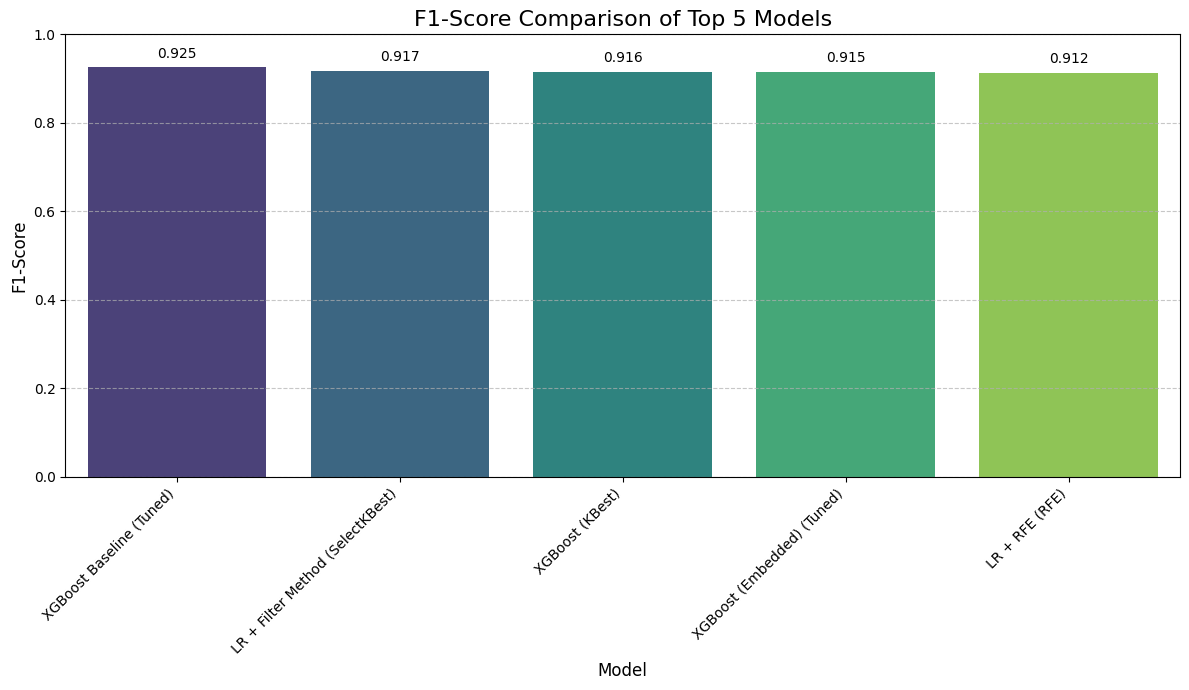

In [257]:
# Create a mapping for more professional labels
def create_model_label(row):
    if row['Experiment'] == 'Tuned':
        return f"{row['Model']} (Tuned)"
    elif row['Experiment'] == 'Baseline_LogisticRegression':
        return 'Logistic Regression (Baseline)'
    elif row['Experiment'] == 'No_Feature_Selection':
        return 'XGBoost (No Feature Selection)'
    else:
        return f"{row['Model']} ({row['Experiment']})"

comparison['Model_Experiment_Label'] = comparison.apply(create_model_label, axis=1)

# Sort the DataFrame by F1 score for better visualization
f1_sorted_comparison = comparison.sort_values(by='F1', ascending=False)

# Select only the top 5 models
f1_sorted_comparison_top5 = f1_sorted_comparison.head(5)

# Plotting the bar chart for F1 scores
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Model_Experiment_Label', y='F1', data=f1_sorted_comparison_top5, palette='viridis')
plt.title('F1-Score Comparison of Top 5 Models', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.ylim(0.0, 1.0) # Adjust y-axis limit to show full range from 0
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add F1 score at the top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

In [252]:
f1_sorted_comparison_top5


,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment,Model_Experiment_Label
11,0.942149,0.935252,0.915493,0.925267,0.978101,XGBoost Baseline,Tuned,XGBoost Baseline (Tuned)
2,0.935262,0.915789,0.919014,0.917399,0.969656,LR + Filter Method,SelectKBest,LR + Filter Method (SelectKBest)
7,0.935262,0.930909,0.901408,0.915921,0.959196,XGBoost,KBest,XGBoost (KBest)
12,0.933884,0.921429,0.908451,0.914894,0.977176,XGBoost (Embedded),Tuned,XGBoost (Embedded) (Tuned)
3,0.932507,0.933579,0.890845,0.911712,0.972735,LR + RFE,RFE,LR + RFE (RFE)


**7.3. Comparison by ROC_AUC**

In [244]:
comparison.sort_values(by='ROC_AUC', ascending=False) # seperation ability

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment,Model_Experiment_Label
11,0.942149,0.935252,0.915493,0.925267,0.978101,XGBoost Baseline,Tuned,XGBoost Baseline (Tuned)
12,0.933884,0.921429,0.908451,0.914894,0.977176,XGBoost (Embedded),Tuned,XGBoost (Embedded) (Tuned)
9,0.926997,0.908127,0.904930,0.906526,0.974516,XGBoost (Embedded),Embedded_XGB,XGBoost (Embedded) (Embedded_XGB)
6,0.929752,0.908772,0.911972,0.910369,0.973886,XGBoost,No_Feature_Selection,XGBoost (No Feature Selection)
3,0.932507,0.933579,0.890845,0.911712,0.972735,LR + RFE,RFE,LR + RFE (RFE)
10,0.924242,0.896194,0.911972,0.904014,0.971632,LR + RFE,Tuned,LR + RFE (Tuned)
4,0.928375,0.911348,0.904930,0.908127,0.970341,LR + Embedded,Embedded,LR + Embedded (Embedded)
2,0.935262,0.915789,0.919014,0.917399,0.969656,LR + Filter Method,SelectKBest,LR + Filter Method (SelectKBest)
8,0.928375,0.889262,0.933099,0.910653,0.967374,XGBoost + RFE,Wrapper_RFE,XGBoost + RFE (Wrapper_RFE)
7,0.935262,0.930909,0.901408,0.915921,0.959196,XGBoost,KBest,XGBoost (KBest)


**7.4. Comparison by Accuracy**

In [245]:
comparison.sort_values(by='Accuracy', ascending=False)

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment,Model_Experiment_Label
11,0.942149,0.935252,0.915493,0.925267,0.978101,XGBoost Baseline,Tuned,XGBoost Baseline (Tuned)
7,0.935262,0.930909,0.901408,0.915921,0.959196,XGBoost,KBest,XGBoost (KBest)
2,0.935262,0.915789,0.919014,0.917399,0.969656,LR + Filter Method,SelectKBest,LR + Filter Method (SelectKBest)
12,0.933884,0.921429,0.908451,0.914894,0.977176,XGBoost (Embedded),Tuned,XGBoost (Embedded) (Tuned)
3,0.932507,0.933579,0.890845,0.911712,0.972735,LR + RFE,RFE,LR + RFE (RFE)
6,0.929752,0.908772,0.911972,0.910369,0.973886,XGBoost,No_Feature_Selection,XGBoost (No Feature Selection)
8,0.928375,0.889262,0.933099,0.910653,0.967374,XGBoost + RFE,Wrapper_RFE,XGBoost + RFE (Wrapper_RFE)
4,0.928375,0.911348,0.904930,0.908127,0.970341,LR + Embedded,Embedded,LR + Embedded (Embedded)
9,0.926997,0.908127,0.904930,0.906526,0.974516,XGBoost (Embedded),Embedded_XGB,XGBoost (Embedded) (Embedded_XGB)
10,0.924242,0.896194,0.911972,0.904014,0.971632,LR + RFE,Tuned,LR + RFE (Tuned)


**7.5. Comparison by Precision**

In [246]:
comparison.sort_values(by='Precision', ascending=False)

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment,Model_Experiment_Label
11,0.942149,0.935252,0.915493,0.925267,0.978101,XGBoost Baseline,Tuned,XGBoost Baseline (Tuned)
3,0.932507,0.933579,0.890845,0.911712,0.972735,LR + RFE,RFE,LR + RFE (RFE)
7,0.935262,0.930909,0.901408,0.915921,0.959196,XGBoost,KBest,XGBoost (KBest)
12,0.933884,0.921429,0.908451,0.914894,0.977176,XGBoost (Embedded),Tuned,XGBoost (Embedded) (Tuned)
2,0.935262,0.915789,0.919014,0.917399,0.969656,LR + Filter Method,SelectKBest,LR + Filter Method (SelectKBest)
4,0.928375,0.911348,0.904930,0.908127,0.970341,LR + Embedded,Embedded,LR + Embedded (Embedded)
6,0.929752,0.908772,0.911972,0.910369,0.973886,XGBoost,No_Feature_Selection,XGBoost (No Feature Selection)
9,0.926997,0.908127,0.904930,0.906526,0.974516,XGBoost (Embedded),Embedded_XGB,XGBoost (Embedded) (Embedded_XGB)
10,0.924242,0.896194,0.911972,0.904014,0.971632,LR + RFE,Tuned,LR + RFE (Tuned)
1,0.922865,0.893103,0.911972,0.902439,0.920918,Logistic regression,Baseline_LogisticRegression,Logistic Regression (Baseline)


**7.6. Comparison by Recall**

In [247]:
comparison.sort_values(by='Recall', ascending=False)

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment,Model_Experiment_Label
8,0.928375,0.889262,0.933099,0.910653,0.967374,XGBoost + RFE,Wrapper_RFE,XGBoost + RFE (Wrapper_RFE)
2,0.935262,0.915789,0.919014,0.917399,0.969656,LR + Filter Method,SelectKBest,LR + Filter Method (SelectKBest)
11,0.942149,0.935252,0.915493,0.925267,0.978101,XGBoost Baseline,Tuned,XGBoost Baseline (Tuned)
1,0.922865,0.893103,0.911972,0.902439,0.920918,Logistic regression,Baseline_LogisticRegression,Logistic Regression (Baseline)
10,0.924242,0.896194,0.911972,0.904014,0.971632,LR + RFE,Tuned,LR + RFE (Tuned)
6,0.929752,0.908772,0.911972,0.910369,0.973886,XGBoost,No_Feature_Selection,XGBoost (No Feature Selection)
12,0.933884,0.921429,0.908451,0.914894,0.977176,XGBoost (Embedded),Tuned,XGBoost (Embedded) (Tuned)
4,0.928375,0.911348,0.904930,0.908127,0.970341,LR + Embedded,Embedded,LR + Embedded (Embedded)
9,0.926997,0.908127,0.904930,0.906526,0.974516,XGBoost (Embedded),Embedded_XGB,XGBoost (Embedded) (Embedded_XGB)
7,0.935262,0.930909,0.901408,0.915921,0.959196,XGBoost,KBest,XGBoost (KBest)


**Clustered Bar Chart Comparison of All Metrices for the Selected Models**

- Logistic Regression (Baseline)
- LR + RFE (untuned)
- Tuned LR + RFE
- XGBoost (No Feature Selection)
- Tuned XGBoost

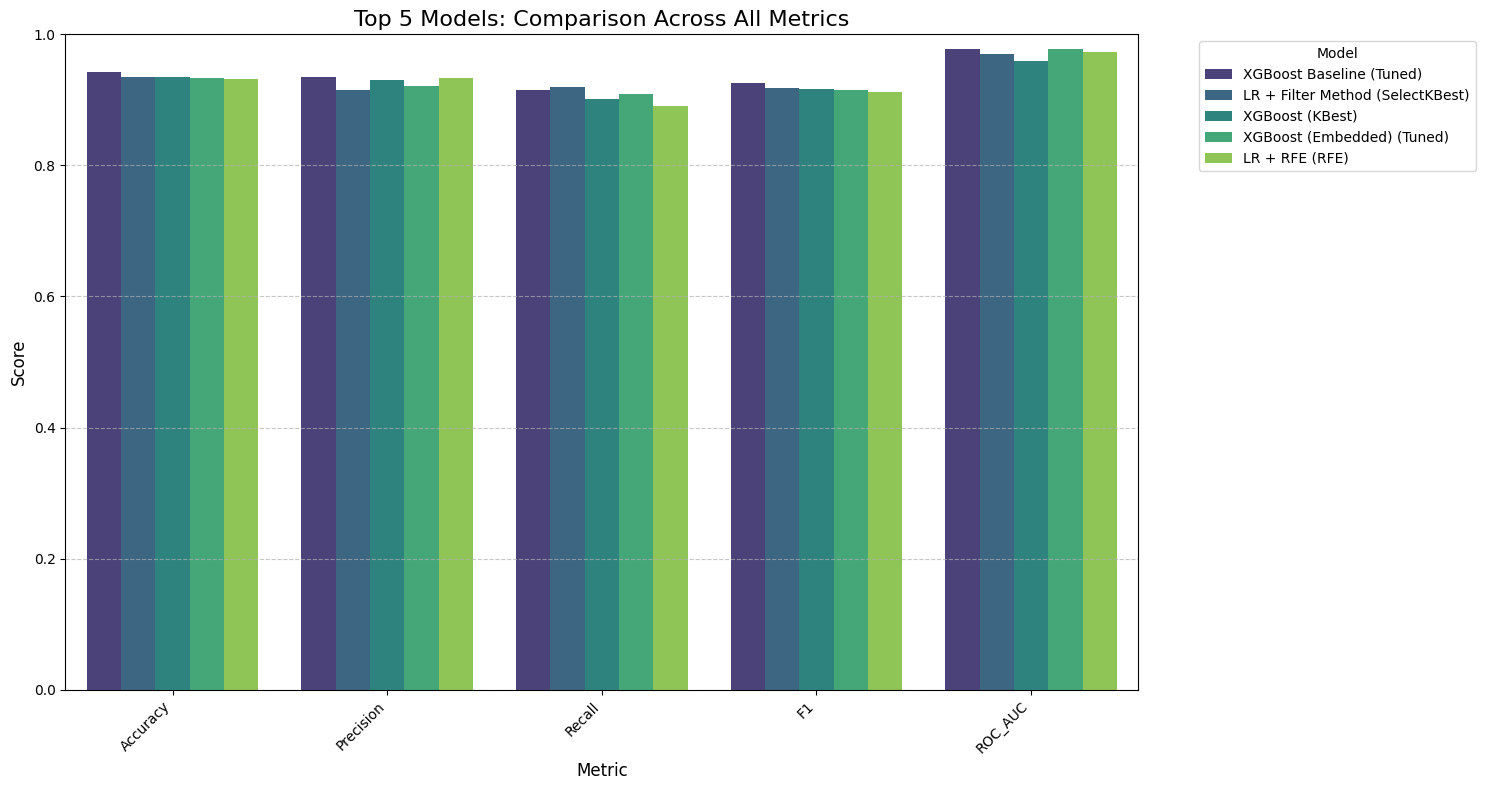

In [256]:
# Sort the DataFrame by F1 score for better visualization and select the top 5
f1_sorted_comparison = comparison.sort_values(by='F1', ascending=False)
f1_sorted_comparison_top5 = f1_sorted_comparison.head(5).copy() # Use .copy() to avoid SettingWithCopyWarning

# Create a mapping for more professional labels if not already present
# (Ensuring the function is defined in this scope)
def create_model_label(row):
    if row['Experiment'] == 'Tuned':
        return f"{row['Model']} (Tuned)"
    elif row['Experiment'] == 'Baseline_LogisticRegression':
        return 'Logistic Regression (Baseline)'
    elif row['Experiment'] == 'No_Feature_Selection':
        return 'XGBoost (No Feature Selection)'
    else:
        return f"{row['Model']} ({row['Experiment']})"

f1_sorted_comparison_top5['Model_Experiment_Label'] = f1_sorted_comparison_top5.apply(create_model_label, axis=1)

# Metrics to compare
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']

# Melt the DataFrame to long format for easy plotting
melted_top5_comparison = f1_sorted_comparison_top5.melt(
    id_vars=['Model_Experiment_Label'],
    value_vars=metrics,
    var_name='Metric',
    value_name='Score'
)

# Plotting the clustered bar chart
plt.figure(figsize=(15, 8))
ax = sns.barplot(
    x='Metric',
    y='Score',
    hue='Model_Experiment_Label',
    data=melted_top5_comparison,
    palette='viridis' # Using viridis palette
)
plt.title('Top 5 Models: Comparison Across All Metrics', fontsize=16)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0.0, 1.0) # Ensure y-axis covers the full range of scores
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## **8. Confusion Matrix for the Best Model: Tuned XGBoost Baseline**

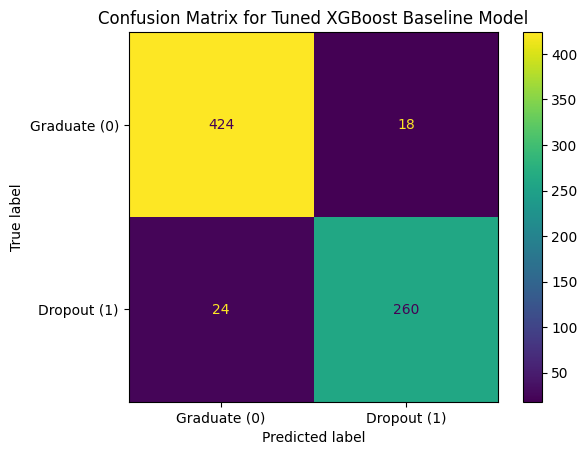

In [258]:
# Generate Confusion matrix for the model with highest F1 score (XGBoost Baseline, tuned)

# Make predictions on the test set
y_pred = best_xgb_model.predict(X_test)

# Create a confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix visually
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Graduate (0)', 'Dropout (1)']
).plot()

plt.title('Confusion Matrix for Tuned XGBoost Baseline Model')
plt.show()

In [259]:
cm

array([[424,  18],
       [ 24, 260]])

**Classification Report for the Tuned XGBoost Baseline**

In [261]:
# Generate classification report for the Tuned XGBoost Baseline
print("Classification Report for Tuned XGBoost Baseline Model:\n")
print(classification_report(y_test, y_pred_tuned_xgb))

Classification Report for Tuned XGBoost Baseline Model:

              precision    recall  f1-score   support

           0       0.95      0.96      0.95       442
           1       0.94      0.92      0.93       284

    accuracy                           0.94       726
   macro avg       0.94      0.94      0.94       726
weighted avg       0.94      0.94      0.94       726



## **9. Feature Importance**

**Feature Importance Plot for the Tuned XGBoost Baseline Model**

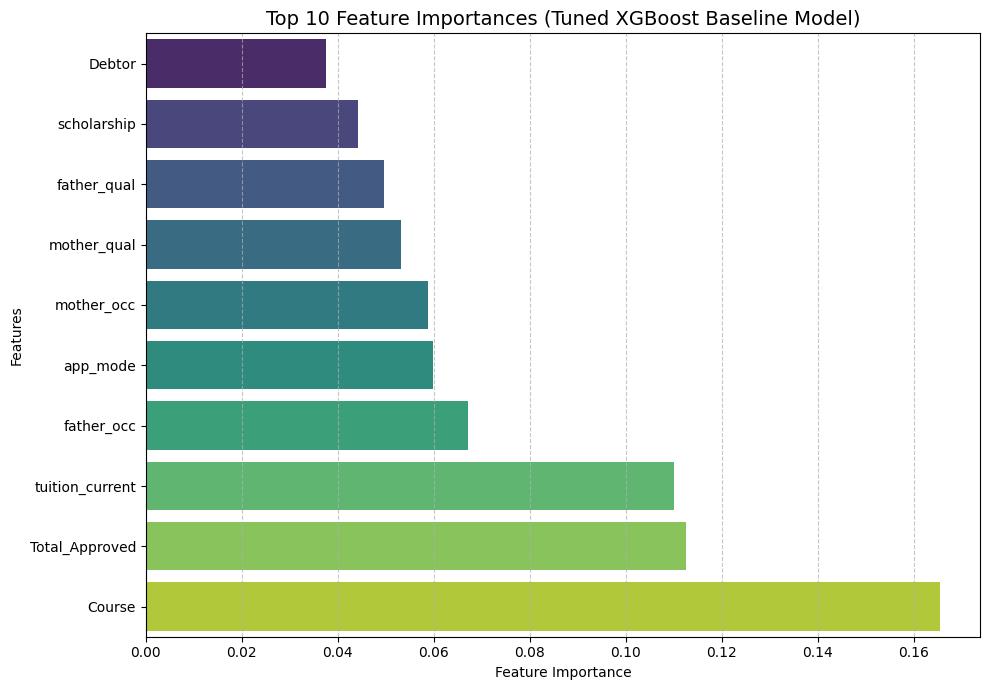

In [263]:
from sklearn.inspection import permutation_importance

# Get the XGBoost classifier from the tuned model pipeline
xgb_classifier = best_xgb_model.named_steps['classifier']

# Get the feature names after preprocessing
preprocessor_output_features = best_xgb_model.named_steps['preprocessor'].get_feature_names_out()

# Get feature importances
importances = xgb_classifier.feature_importances_

# Create a temporary DataFrame for feature importance
importance_df_temp = pd.DataFrame({
    'Feature': preprocessor_output_features,
    'Importance': importances
})

# --- Cleaning feature names for display and aggregation ---
cleaned_features_list = []
for col in importance_df_temp['Feature']:
    if col.startswith('remainder__'):
        # It's a numerical feature passed through, remove prefix
        cleaned_features_list.append(col.replace('remainder__', ''))
    elif col.startswith('cat__'):
        # It's a one-hot encoded categorical feature
        clean_cat_col = col.replace('cat__', '')
        # Find the original categorical column name
        original_cat_name = None
        for cat_col_name in categorical_cols:
            if clean_cat_col.startswith(cat_col_name + '_'):
                original_cat_name = cat_col_name
                break
        if original_cat_name:
            cleaned_features_list.append(original_cat_name)
        else:
            # Fallback for unexpected OHE format
            cleaned_features_list.append(clean_cat_col)
    else:
        # Keep as is if no prefix or special handling is needed
        cleaned_features_list.append(col)

# Add the cleaned feature names to the DataFrame
importance_df_temp['Cleaned_Feature'] = cleaned_features_list

# Aggregate importance for original categorical features (sum of importances of their OHE parts)
aggregated_importance = importance_df_temp.groupby('Cleaned_Feature')['Importance'].sum().reset_index()
aggregated_importance.columns = ['Feature', 'Importance']

# Sort and take top 15 features
top_features = aggregated_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

# Plot
plt.figure(figsize=(10, 7))
sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features.sort_values(by='Importance', ascending=True),
    palette='viridis'
)

# Labels and title
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 10 Feature Importances (Tuned XGBoost Baseline Model)', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Interpretation of Feature Importance for Tuned XGBoost Baseline Model**

The feature importance plot above displays the top 10 features that contribute most to the Tuned XGBoost Baseline model's predictions, ranked by their importance score. A higher score indicates a stronger influence on the likelihood of a student dropping out.

**Key Observations from the Top 10 Features:**

*   **'Course'** is overwhelmingly the most significant feature, with a substantial importance score of **0.165**. This reconfirms its critical role, suggesting that the specific academic program a student enrolls in is a primary driver of retention outcomes. Factors such as curriculum rigor, support systems, or student demographics within different courses likely contribute to this.

*   **'Total_Approved'** (total approved curricular units) and **'tuition_current'** (whether tuition fees are up-to-date) are the next most influential features, with importance scores of **0.112** and **0.110**, respectively. This underscores the strong connection between sustained academic progress (passing courses) and financial stability with student retention. Students who successfully complete more units and manage their tuition payments are much less likely to drop out.

*   **Socioeconomic factors** like **'father_occ'** (father's occupation, importance 0.067) and **'mother_occ'** (mother's occupation, importance 0.058) also play a notable role, indicating that parental background can influence a student's educational trajectory.

*   **'app_mode'** (application mode, importance 0.059) and **'mother_qual'** (mother's qualification, importance 0.053) are significant, highlighting the impact of how a student enters the institution and the educational background of their mother.

*   **'scholarship'** (scholarship holder, importance 0.044) and **'Debtor'** (student debtor status, importance 0.037) remain important financial indicators. The presence of a scholarship tends to reduce dropout risk, while being a debtor increases it, reinforcing the crucial role of financial support and burden.

*   **'father_qual'** (father's qualification, importance 0.049) also features in the top 10.

**Overall Insights:**

The Tuned XGBoost Baseline model emphasizes a multi-faceted view of student retention, where **academic factors (especially 'Course' and 'Total_Approved') are paramount**. Financial stability and support (tuition status, scholarship, debt) are also critical. Furthermore, socioeconomic background (parents' occupations and qualifications) and institutional entry pathways ('app_mode') significantly contribute to predicting student dropout. This comprehensive understanding allows for more targeted and effective intervention strategies.